In [1]:
import pandas as pd
from data_validation import *

df = pd.read_csv('/Users/semolik/PyCharmMiscProject/hakaton.csv', sep=';', encoding='utf-8')


In [2]:
df

,last_name,first_name,middle_name,bdate,gender,id_doc,guard_last_name,guard_first_name,guard_middle_name,guard_bdate,...,guard_id_doc,our_number,ogrn_naprav,name_naprav,ogrn_area,name_area,variant,class,test_date,result
0,МУСЮС,АЛЕКСАНДР,NaN,2013-07-16,М,240045105,АГАФОНОВА,КЛАВДИЯ,NaN,1987-07-06,...,106077198701603,26-11-60078-000038-4,1022402487304,муниципальное автономное общеобразовательное у...,1142452001130,краевое бюджетное общеобразовательное учрежден...,20611,6,2026-02-25,Недостаточный
1,СОБОЛЕВ,ЮРИЙ,ГЕННАДЬЕВИЧ,2018-01-26,М,-1236233,КАБЛИН,ВАЛЕНТИН,ГЕННАДИЕВИЧ,1991-03-15,...,1571302,25-11-70122-000036-6,1025007390077,МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ ОБЩЕОБРАЗОВАТЕЛЬНОЕ УЧ...,1035004258970,МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ ОБЩЕОБРАЗОВАТЕЛЬНОЕ УЧ...,120126,1,2025-12-16,Недостаточный
2,РЯБОВ,ГЕННАДИЙ,СЕРГЕЕВИЧ,2014-08-21,М,5974549,ЗАКИРОВ,БОРИС,СЕРГЕЕВИЧ,1990-03-07,...,5480835,26-11-70285-000004-4,1037816029393,ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ ОБЩЕОБРАЗОВАТЕЛЬНОЕ ...,1037816029547,Государственное бюджетное общеобразовательное ...,10410,4,2026-01-20,Достаточный
3,БОРИСОВ,АНАТОЛИЙ,НИКОЛЛАЕВИЧ,2018-07-22,М,3702355,ДЖАЛОЛОВ,ЕВГЕНИЙ,АНДРАНИКОВИЧ,1992-08-23,...,402238324,26-11-70046-000006-7,1021603470360,Муниципальное бюджетное общеобразовательное уч...,1241600037315,Муниципальное бюджетное общеобразовательное уч...,20133,1,2026-02-04,Недостаточный
4,КАРПЕВИЧ,ВИКТОР,ЮРЬЕВИЧ,2019-01-18,М,0000000,ШАПРАН,ЕЛЕНА,ПАВЛОВНА,1995-01-17,...,0352905,25-11-60108-000020-9,1023402988234,муниципальное общеобразовательное учреждение С...,1023402982173,"муниципальное общеобразовательное учреждение ""...",60105,1,2025-06-10,достаточный
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25623,ЛАЗАРЕВ,ДЕНИС,ВЛАДИМИРОВИЧ,2015-06-28,М,2118425,ЛАЗАРЕВ,ВАЛЕРИЙ,ПЕТРОВИЧ,1991-10-06,...,402450094,25-11-70289-000015-7,1022701291250,муниципальное автономное общеобразовательное у...,1022701289170,муниципальное бюджетное общеобразовательное уч...,60304,3,2025-07-14,Недостаточный
25624,ВИДАКОВ,МИХАИЛ,СЕРГЕЕВИЧ,2018-03-06,М,010080310,КРАСНОКУТСКИЙ,ИЛЬЯ,ВЛАДИМИРОВИЧ,1991-11-07,...,4127610,25-11-70289-000009-8,1022701286508,муниципальное автономное общеобразовательное у...,1022701289170,муниципальное бюджетное общеобразовательное уч...,80110,1,2025-08-27,Недостаточный
25625,ТОЛОКОНУШКОВ,ЕВГЕНИЙ,ФЕДОРОВИЧ,2018-04-14,М,-N0849879,ВАСИЛЕНКО,БОРИС,СЕРГЕЕВИЧ,1978-10-02,...,2920197,25-11-70289-000014-8,1022701283208,муниципальное автономное общеобразовательное у...,1022701289170,муниципальное бюджетное общеобразовательное уч...,80109,1,2025-08-27,Достаточный
25626,ТИХОНОВ,ВЛАДИМИР,АЛЕКСАНДРОВИЧ,2017-09-11,М,21109201751729,МИРЗОЯН,ВЛАДИМИР,АЛЕКСАНДРОВИЧ,1987-05-17,...,3196439,25-11-70289-000019-9,1022701291250,муниципальное автономное общеобразовательное у...,1022701289170,муниципальное бюджетное общеобразовательное уч...,90114,1,2025-09-25,Недостаточный


In [3]:
df['is_invalid'] = False
df['is_logical_error'] = False
df['same_doc_id_error'] = False
df['is_tech_error'] = False
df['is_duplicated'] = False

In [4]:
df.columns

Index(['last_name', 'first_name', 'middle_name', 'bdate', 'gender', 'id_doc',
       'guard_last_name', 'guard_first_name', 'guard_middle_name',
       'guard_bdate', 'guard_gender', 'guard_id_doc', 'our_number',
       'ogrn_naprav', 'name_naprav', 'ogrn_area', 'name_area', 'variant',
       'class', 'test_date', 'result', 'is_invalid', 'is_logical_error',
       'same_doc_id_error', 'is_tech_error', 'is_duplicated'],
      dtype='object')

In [5]:
# ========== БЛОК: НОРМАЛИЗАЦИЯ id_doc И guard_id_doc К INT ==========
print("\n" + "="*60)
print("НОРМАЛИЗАЦИЯ id_doc И guard_id_doc")
print("="*60)

for col in ['id_doc', 'guard_id_doc']:
    if col in df.columns:
        # Сохраняем оригинальные значения для сравнения
        original = df[col].astype(str).copy()

        # Удаляем буквы, оставляя только цифры и точки/минусы
        df[col] = df[col].astype(str).str.replace(r'[^0-9.-]', '', regex=True)

        # Заменяем пустые строки на NaN
        df[col] = df[col].replace('', None)

        # Считаем количество измененных значений
        changed_mask = (original != df[col].astype(str))
        changed = changed_mask.sum()

        # Преобразуем в числовой тип (float для обработки дробных чисел)
        df[col] = pd.to_numeric(df[col], errors='coerce')

        # Пометить некорректные id_doc/guard_id_doc как is_tech_error
        df.loc[changed_mask, 'is_tech_error'] = True

        # Оставляем NaN и inf как они есть (float64)
        # Не преобразуем в int, чтобы сохранить NaN/inf

        print(f"\n✅ {col}:")
        print(f"   Нормализовано записей: {changed} ({changed/len(df)*100:.2f}%)")
        print(f"   Тип данных: Int64")



НОРМАЛИЗАЦИЯ id_doc И guard_id_doc

✅ id_doc:
   Нормализовано записей: 4847 (18.91%)
   Тип данных: Int64

✅ guard_id_doc:
   Нормализовано записей: 3981 (15.53%)
   Тип данных: Int64


result (Результат тестирования)
Проблема: 7 уникальных значений с разными регистрами

"Достаточный" (39.4%)
"достаточный" (8.4%)
"ДОСТАТОЧНЫЙ" (0.7%)
"НЕдостаточный" (0.0%) - ошибка ввода!
"Недостаточный" (43.5%)
"недостаточный" (7.8%)
"НЕДОСТАТОЧНЫЙ" (0.2%)

In [6]:
df['result_normalized'] = df['result'].str.upper().str.strip()
df['result_code'] = df['result_normalized'].apply(lambda x:
    1 if 'ДОСТАТОЧ' in x else 0)

In [7]:
df['guard_gender_code'] = (df['guard_gender'] == "М").astype(int)

In [8]:
df['bdate'] = pd.to_datetime(df['bdate'])

In [9]:
df['test_date'] = pd.to_datetime(df['test_date'])
df['age_years'] = ((df['test_date'] - df['bdate']).dt.days / 365).astype(int)
df['guard_bdate'] = pd.to_datetime(df['guard_bdate'])
df['guard_age_years'] =((df['test_date'] - df['guard_bdate']).dt.days / 365).astype(int)


In [10]:
# Рассчитаем возраст на 1 сентября года тестирования (для проверки по закону РФ)
# Минимальный возраст для поступления в 1 класс: 6 лет 6 месяцев на 1 сентября
september_1 = pd.to_datetime(df['test_date'].dt.year.astype(str) + '-09-01')
age_at_september = ((september_1 - df['bdate']).dt.days / 365.25)

# Проверка 1: Возраст менее 6.5 лет на 1 сентября (ниже минимума по закону РФ)
too_young_mask = age_at_september < 6.5
df.loc[too_young_mask, 'is_logical_error'] = True

print(f"⚠️  Возраст < 6.5 лет на 1 сентября: {too_young_mask.sum()}")

⚠️  Возраст < 6.5 лет на 1 сентября: 127


In [11]:
# Проверка 1: Дата рождения позже даты тестирования (невозможное)
invalid_dates_mask = df['bdate'] > df['test_date']
df.loc[invalid_dates_mask, 'is_logical_error'] = True

print(f"\n❌ Записей, где дата рождения ПОЗЖЕ даты тестирования: {invalid_dates_mask.sum()}")


❌ Записей, где дата рождения ПОЗЖЕ даты тестирования: 1


In [12]:
df['gender'] =  (df['gender'] == "М").astype(int)


In [13]:

numeric_class = pd.to_numeric(df['class'], errors='coerce')

non_int_mask = numeric_class.isnull() | (numeric_class != numeric_class.astype('Int64', errors='ignore').astype(float))

# Пометить строки с не-целыми значениями как is_invalid
df.loc[non_int_mask, 'is_invalid'] = True

invalid_count = non_int_mask.sum()
print(f"\n⚠️  Строк с не-целыми значениями в 'class': {invalid_count}")

if invalid_count > 0:
    print("\n🔴 Примеры проблемных строк:")
    print(df[non_int_mask][['class', 'is_invalid']].head(10).to_string())




⚠️  Строк с не-целыми значениями в 'class': 1

🔴 Примеры проблемных строк:
      class  is_invalid
18393   2-5        True


In [14]:
# ========== БЛОК: ПРОВЕРКА ОТРИЦАТЕЛЬНЫХ ЗНАЧЕНИЙ ID ==========
print("\n" + "="*60)
print("ПРОВЕРКА ОТРИЦАТЕЛЬНЫХ ЗНАЧЕНИЙ ID")
print("="*60)

def check_negative_column(col_name, display_cols, df_ref):
    mask = (df_ref[col_name] < 0) & df_ref[col_name].notna()
    count = mask.sum()
    if count > 0:
        df_ref.loc[mask, 'is_tech_error'] = True
        print(f"⚠️  {col_name}: {count} отрицательных ({count/len(df_ref)*100:.2f}%)")
    return {'count': count, 'percent': count/len(df_ref)*100 if count > 0 else 0}

for col in ['id_doc', 'guard_id_doc']:
    if col in df.columns:
        cols = ['id_doc', 'last_name', 'first_name'] if col == 'id_doc' else ['guard_id_doc', 'guard_last_name', 'guard_first_name']
        check_negative_column(col, cols, df)



ПРОВЕРКА ОТРИЦАТЕЛЬНЫХ ЗНАЧЕНИЙ ID
⚠️  id_doc: 4286 отрицательных (16.72%)
⚠️  guard_id_doc: 25 отрицательных (0.10%)


In [15]:
# ========== БЛОК: ПОИСК СОВПАДЕНИЙ id_doc И guard_id_doc ==========
print("\n" + "="*60)
print("ПОИСК СОВПАДЕНИЙ id_doc И guard_id_doc")
print("="*60)

if all(col in df.columns for col in ['id_doc', 'guard_id_doc']):
    non_null = df['id_doc'].notna() & df['guard_id_doc'].notna()
    match = (df['id_doc'] == df['guard_id_doc']) & non_null
    cnt = match.sum()

    print(f"📊 Всего: {len(df)} | Совпадений: {cnt} ({cnt/len(df)*100:.2f}%)")

    if cnt > 0:
        df.loc[match, 'same_doc_id_error'] = True
        print(f"✅ Отмечено {cnt} строк как is_tech_error")

    else:
        print("✅ Совпадений не найдено")



ПОИСК СОВПАДЕНИЙ id_doc И guard_id_doc
📊 Всего: 25628 | Совпадений: 347 (1.35%)
✅ Отмечено 347 строк как is_tech_error


In [16]:
# ========== КОНСТАНТЫ: ИСКЛЮЧЕНИЯ ДЛЯ ИМЁН ==========
# Женские имена (pymorphy2 определяет неправильно или это ошибочно указанные в данных как мужские)
FEMALE_NAMES_EXCEPTIONS = {
    'антонина', 'евгения', 'бронислава', 'антонида', 'серафима',
    'валерия', 'эльмира', 'апполинария', 'анжела', 'миниса', 'федосия', 'федора',
    'алена', 'асия', 'альфия', 'павла', 'натия', 'майка', 'халида', 'лала',
    'варвара', 'владислава', 'яна',
    'тигрануии', 'алефтина',
    # Ошибочно указаны как мужские в данных (gender=1):
    'ольга', 'елена', 'камия', 'таисия', 'александра', 'римма'
}

# Мужские имена
MALE_NAMES_EXCEPTIONS = {
    'ивлиане', 'илтизир',
    'михаил'
}


In [17]:
print("\n" + "="*60)
print("ПРОВЕРКА СООТВЕТСТВИЯ ПОЛА И ИМЕНИ (pymorphy2 + исключения)")
print("="*60)

try:
    import pymorphy2
    morph = pymorphy2.MorphAnalyzer()

    gender_mismatch = 0
    mismatch_details = []

    for idx, row in df.iterrows():
        if pd.notna(row['gender']) and pd.notna(row['first_name']):
            name = str(row['first_name']).strip()
            name_lower = name.lower()
            expected_gender = 'femn' if row['gender'] == 0 else 'masc'

            if name_lower in FEMALE_NAMES_EXCEPTIONS:
                actual_gender = 'femn'
            elif name_lower in MALE_NAMES_EXCEPTIONS:
                actual_gender = 'masc'
            else:
                # Анализируем имя через pymorphy2
                parsed = morph.parse(name)[0]
                grammemes = parsed.tag.grammemes
                actual_gender = 'femn' if 'femn' in grammemes else ('masc' if 'masc' in grammemes else 'unknown')
            # Проверяем на несоответствие
            if actual_gender != 'unknown' and actual_gender != expected_gender:
                df.loc[idx, 'is_logical_error'] = True
                gender_mismatch += 1
                expected_str = 'женское' if expected_gender == 'femn' else 'мужское'
                actual_str = 'женское' if actual_gender == 'femn' else 'мужское'
                mismatch_details.append({
                    'name': name,
                    'expected': expected_str,
                    'actual': actual_str,
                    'error': f"ожидается {expected_str}, определено {actual_str}"
                })

    print(f"\n⚠️  Несоответствия пола и имени: {gender_mismatch} ({gender_mismatch/len(df)*100:.2f}%)")

    if gender_mismatch > 0:
        print(f"   ✅ Отмечено {gender_mismatch} строк как is_invalid")
        print(f"\n   Примеры ошибок (первые 20):")
        for detail in mismatch_details[:20]:
            print(f"      '{detail['name']}': {detail['error']}")
    else:
        print("   ✅ Все имена соответствуют полу!")

except ImportError:
    print("⚠️  Библиотека pymorphy2 не установлена")
    print("   Установите: pip install pymorphy2")
    print("\n   Пропуск проверки имен через библиотеку")



ПРОВЕРКА СООТВЕТСТВИЯ ПОЛА И ИМЕНИ (pymorphy2 + исключения)

⚠️  Несоответствия пола и имени: 14 (0.05%)
   ✅ Отмечено 14 строк как is_invalid

   Примеры ошибок (первые 20):
      'ОЛЬГА': ожидается мужское, определено женское
      'КАМИЯ': ожидается мужское, определено женское
      'ЕЛЕНА': ожидается мужское, определено женское
      'ОЛЬГА': ожидается мужское, определено женское
      'КАМИЯ': ожидается мужское, определено женское
      'АЛЕКСАНДРА': ожидается мужское, определено женское
      'ТАИСИЯ': ожидается мужское, определено женское
      'ТАИСИЯ': ожидается мужское, определено женское
      'КАМИЯ': ожидается мужское, определено женское
      'МИХАИЛ': ожидается женское, определено мужское
      'РИММА': ожидается мужское, определено женское
      'КАМИЯ': ожидается мужское, определено женское
      'ТАИСИЯ': ожидается мужское, определено женское
      'КАМИЯ': ожидается мужское, определено женское


In [18]:
# ========== ИТОГОВАЯ СТАТИСТИКА ==========
print("\n" + "="*60)
print("ИТОГОВАЯ СТАТИСТИКА")
print("="*60)

invalid_count = df['is_invalid'].sum()
total = len(df)
print(f"\n📊 Всего записей: {total}")
print(f"❌ Отмечено как is_invalid: {invalid_count} ({invalid_count/total*100:.2f}%)")
print(f"✅ Корректных: {total - invalid_count} ({(total-invalid_count)/total*100:.2f}%)")



ИТОГОВАЯ СТАТИСТИКА

📊 Всего записей: 25628
❌ Отмечено как is_invalid: 1 (0.00%)
✅ Корректных: 25627 (100.00%)


In [19]:
# ========== ИТОГОВАЯ СТАТИСТИКА ПО НАРУШЕНИЯМ ==========
print("\n" + "="*60)
print("ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ НАРУШЕНИМ")
print("="*60)

invalid_count = df['is_invalid'].sum()
total = len(df)
print(f"\n📊 Общая статистика:")
print(f"   Всего записей: {total}")
print(f"   ❌ Отмечено как is_invalid: {invalid_count} ({invalid_count/total*100:.2f}%)")
print(f"   ✅ Корректных: {total - invalid_count} ({(total-invalid_count)/total*100:.2f}%)")

print(f"\n📈 Распределение статуса:")
print(df['is_invalid'].value_counts().to_string())



ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ НАРУШЕНИМ

📊 Общая статистика:
   Всего записей: 25628
   ❌ Отмечено как is_invalid: 1 (0.00%)
   ✅ Корректных: 25627 (100.00%)

📈 Распределение статуса:
is_invalid
False    25627
True         1


In [20]:
# ========== ГРАФИКИ ПО КЛАССАМ ==========
print("\n" + "="*60)
print("АНАЛИЗ НАРУШЕНИЙ ПО КЛАССАМ")
print("="*60)

import matplotlib.pyplot as plt
import numpy as np

# Преобразуем класс в числовой тип для сортировки
df['class_num'] = pd.to_numeric(df['class'], errors='coerce')

# Статистика по классам
class_stats = df.groupby('class_num').agg({
    'is_invalid': ['sum', 'count'],
    'id_doc': 'count'
}).round(2)

class_stats.columns = ['invalid_count', 'total_in_group', 'total_all']
class_stats['invalid_pct'] = (class_stats['invalid_count'] / class_stats['total_in_group'] * 100).round(2)
class_stats = class_stats.sort_index()

print("\n📊 Статистика по классам:")
print(class_stats.to_string())



АНАЛИЗ НАРУШЕНИЙ ПО КЛАССАМ

📊 Статистика по классам:
           invalid_count  total_in_group  total_all  invalid_pct
class_num                                                       
1.0                    0           12306      12231          0.0
2.0                    0            1839       1815          0.0
3.0                    0            1803       1790          0.0
4.0                    0            1762       1749          0.0
5.0                    0            1952       1935          0.0
6.0                    0            1570       1557          0.0
7.0                    0            1534       1525          0.0
8.0                    0            1354       1340          0.0
9.0                    0             972        965          0.0
10.0                   0             388        386          0.0
11.0                   0             147        147          0.0


/var/folders/th/n3z6xrp16p5bnl3r73s06dfc0000gn/T/ipykernel_68543/737089533.py:22: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/th/n3z6xrp16p5bnl3r73s06dfc0000gn/T/ipykernel_68543/737089533.py:22: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/semolik/PyCharmMiscProject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/semolik/PyCharmMiscProject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


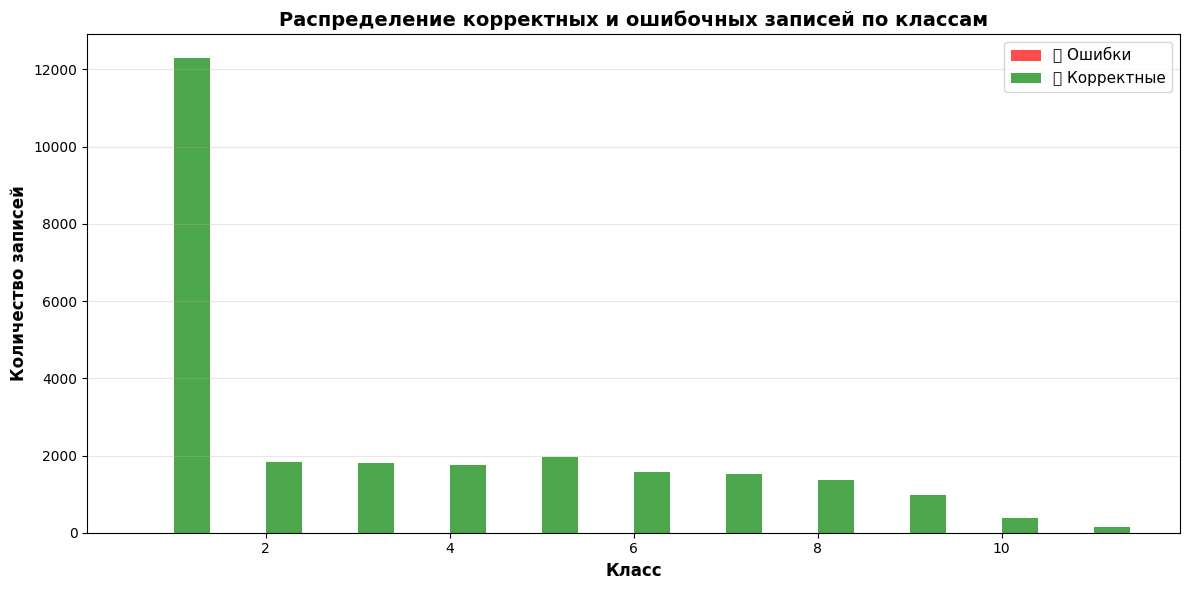

In [21]:
# ========== ГРАФИК 1: АБСОЛЮТНОЕ КОЛИЧЕСТВО НАРУШЕНИЙ ПО КЛАССАМ ==========
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

class_invalid = df[df['is_invalid'] == True].groupby('class_num').size()
class_total = df.groupby('class_num').size()

# Переиндексируем, чтобы выравнять индексы
class_invalid = class_invalid.reindex(class_total.index, fill_value=0)

x = class_total.index

ax.bar(x - 0.2, class_invalid.values, width=0.4, label='❌ Ошибки', color='red', alpha=0.7)
ax.bar(x + 0.2, (class_total - class_invalid).values, width=0.4, label='✅ Корректные', color='green', alpha=0.7)
ax.set_xlabel('Класс', fontsize=12, fontweight='bold')
ax.set_ylabel('Количество записей', fontsize=12, fontweight='bold')
ax.set_title('Распределение корректных и ошибочных записей по классам', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


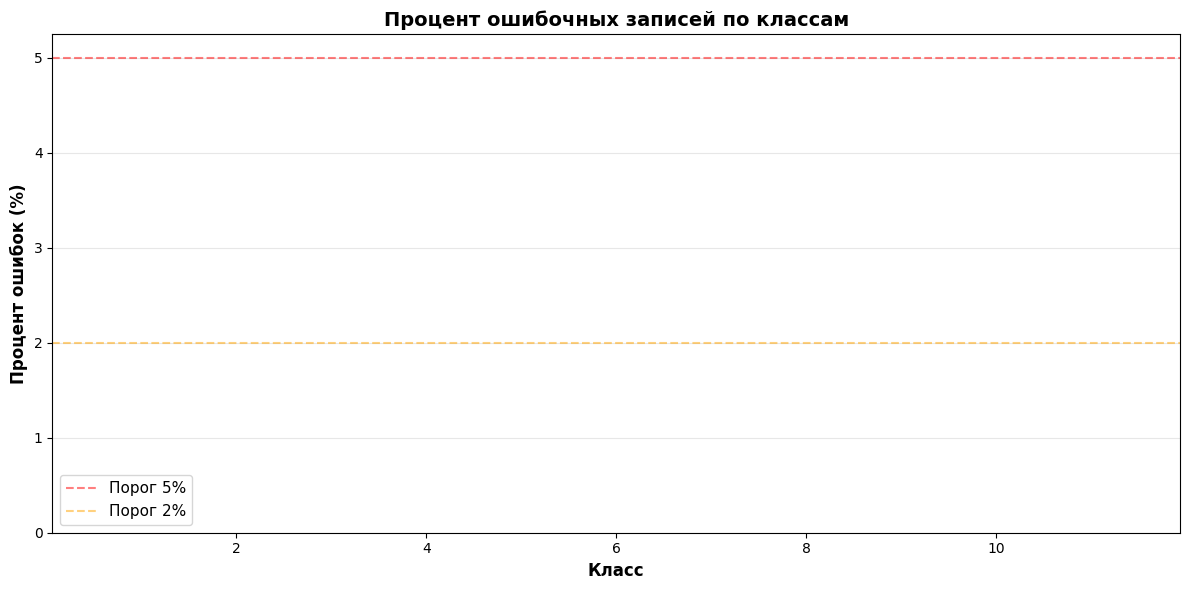

In [22]:
# ========== ГРАФИК 2: ПРОЦЕНТ НАРУШЕНИЙ ПО КЛАССАМ ==========
fig, ax = plt.subplots(figsize=(12, 6))

# Используем переиндексированные значения из предыдущего графика
pct_invalid = (class_invalid / class_total * 100)
colors = ['red' if p > 5 else 'orange' if p > 2 else 'green' for p in pct_invalid.values]

ax.bar(class_total.index, pct_invalid.values, color=colors, alpha=0.7)
ax.set_xlabel('Класс', fontsize=12, fontweight='bold')
ax.set_ylabel('Процент ошибок (%)', fontsize=12, fontweight='bold')
ax.set_title('Процент ошибочных записей по классам', fontsize=14, fontweight='bold')
ax.axhline(y=5, color='red', linestyle='--', label='Порог 5%', alpha=0.5)
ax.axhline(y=2, color='orange', linestyle='--', label='Порог 2%', alpha=0.5)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [23]:
# ========== АНАЛИЗ НАРУШЕНИЙ ПО МЕСЯЦАМ ==========
print("\n" + "="*60)
print("АНАЛИЗ НАРУШЕНИЙ ПО МЕСЯЦАМ")
print("="*60)

# Добавляем колонку с месяцем-годом
df['test_month'] = df['test_date'].dt.to_period('M')
df['test_month_str'] = df['test_date'].dt.strftime('%Y-%m')

# Статистика по месяцам
month_stats = df.groupby('test_month_str').agg({
    'is_invalid': ['sum', 'count']
}).round(2)

month_stats.columns = ['invalid_count', 'total_in_month']
month_stats['invalid_pct'] = (month_stats['invalid_count'] / month_stats['total_in_month'] * 100).round(2)

print(f"\n📊 Всего месяцев: {len(month_stats)}")
print(f"\n🔍 Первые 10 месяцев:")
print(month_stats.head(10).to_string())
print(f"\n🔍 Последние 10 месяцев:")
print(month_stats.tail(10).to_string())



АНАЛИЗ НАРУШЕНИЙ ПО МЕСЯЦАМ

📊 Всего месяцев: 12

🔍 Первые 10 месяцев:
                invalid_count  total_in_month  invalid_pct
test_month_str                                            
2025-04                     0             101         0.00
2025-05                     0             662         0.00
2025-06                     0            1108         0.00
2025-07                     0            1181         0.00
2025-08                     1            5660         0.02
2025-09                     0            5633         0.00
2025-10                     0            3761         0.00
2025-11                     0            2280         0.00
2025-12                     0            2342         0.00
2026-01                     0            1146         0.00

🔍 Последние 10 месяцев:
                invalid_count  total_in_month  invalid_pct
test_month_str                                            
2025-06                     0            1108         0.00
2025-07           

/var/folders/th/n3z6xrp16p5bnl3r73s06dfc0000gn/T/ipykernel_68543/3375079107.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/th/n3z6xrp16p5bnl3r73s06dfc0000gn/T/ipykernel_68543/3375079107.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/semolik/PyCharmMiscProject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/semolik/PyCharmMiscProject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


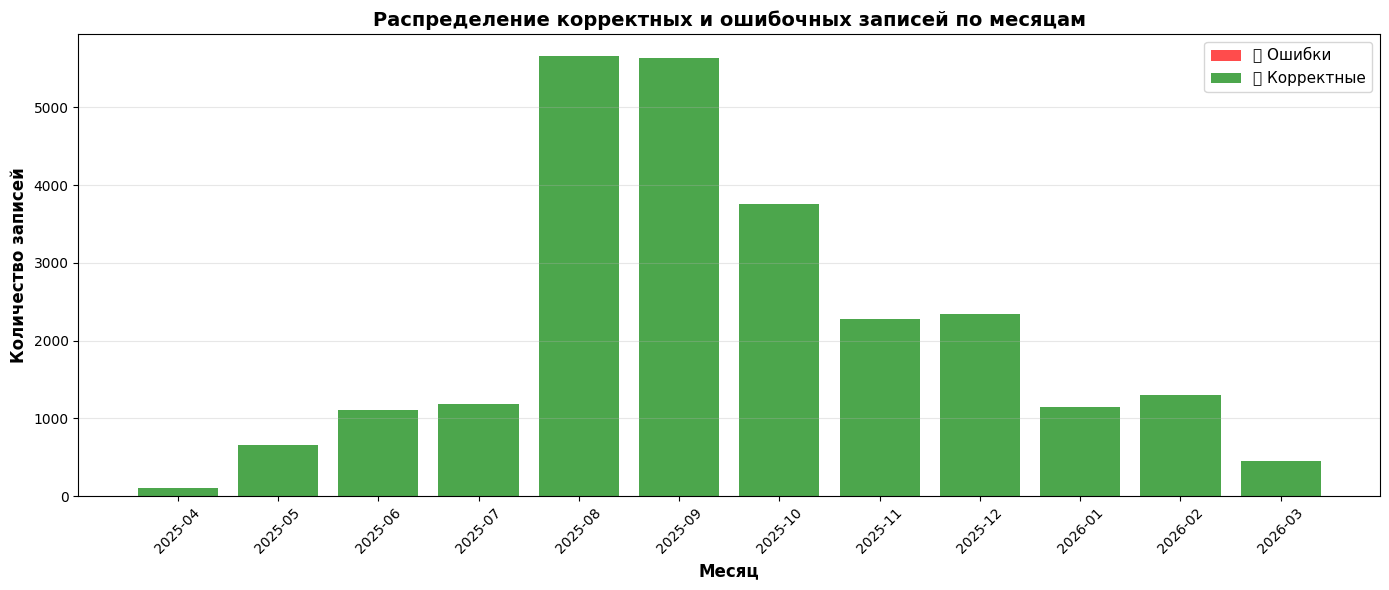

In [24]:
# ========== ГРАФИК 3: АБСОЛЮТНОЕ КОЛИЧЕСТВО НАРУШЕНИЙ ПО МЕСЯЦАМ ==========
fig, ax = plt.subplots(figsize=(14, 6))

months = month_stats.index
invalid_by_month = month_stats['invalid_count'].values
valid_by_month = month_stats['total_in_month'].values - invalid_by_month

ax.bar(range(len(months)), invalid_by_month, label='❌ Ошибки', color='red', alpha=0.7)
ax.bar(range(len(months)), valid_by_month, bottom=invalid_by_month, label='✅ Корректные', color='green', alpha=0.7)
ax.set_xlabel('Месяц', fontsize=12, fontweight='bold')
ax.set_ylabel('Количество записей', fontsize=12, fontweight='bold')
ax.set_title('Распределение корректных и ошибочных записей по месяцам', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, len(months), max(1, len(months) // 12)))
ax.set_xticklabels([months[i] for i in range(0, len(months), max(1, len(months) // 12))], rotation=45)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


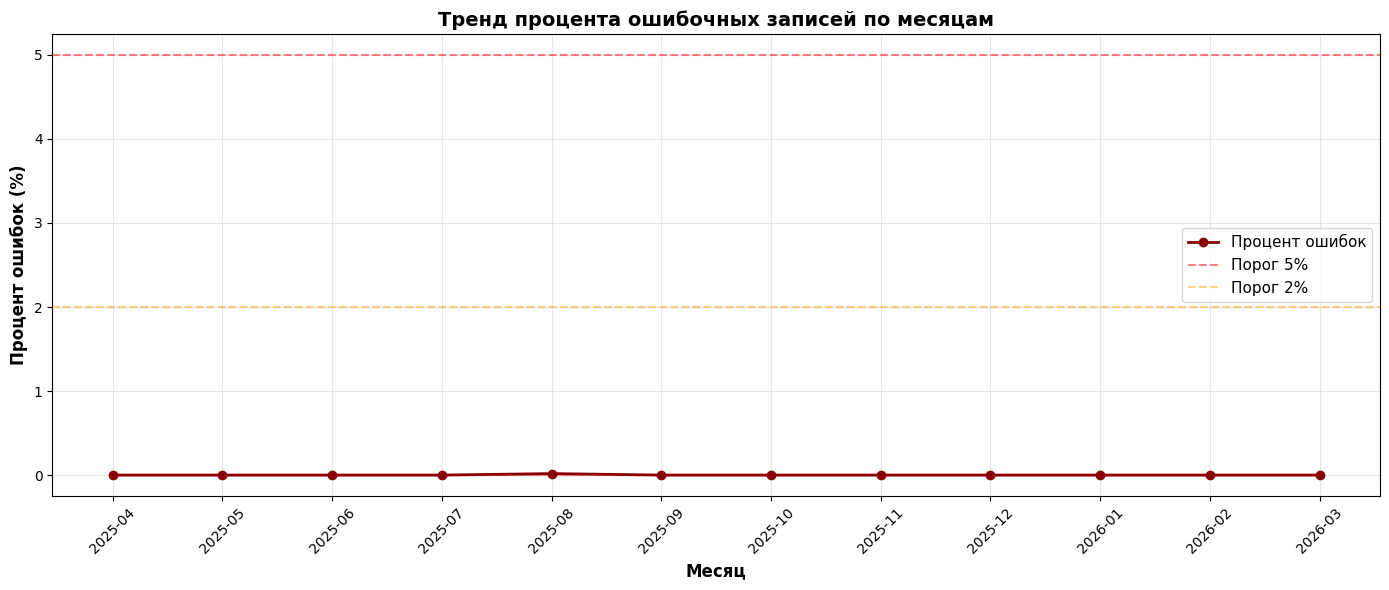


✅ Все графики построены успешно!


In [25]:
# ========== ГРАФИК 4: ПРОЦЕНТ НАРУШЕНИЙ ПО МЕСЯЦАМ (ТРЕНД) ==========
fig, ax = plt.subplots(figsize=(14, 6))

pct_invalid_by_month = (month_stats['invalid_count'] / month_stats['total_in_month'] * 100).values

ax.plot(range(len(months)), pct_invalid_by_month, marker='o', linewidth=2, markersize=6, label='Процент ошибок', color='darkred')
ax.fill_between(range(len(months)), pct_invalid_by_month, alpha=0.3, color='red')
ax.axhline(y=5, color='red', linestyle='--', label='Порог 5%', alpha=0.5)
ax.axhline(y=2, color='orange', linestyle='--', label='Порог 2%', alpha=0.5)
ax.set_xlabel('Месяц', fontsize=12, fontweight='bold')
ax.set_ylabel('Процент ошибок (%)', fontsize=12, fontweight='bold')
ax.set_title('Тренд процента ошибочных записей по месяцам', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, len(months), max(1, len(months) // 12)))
ax.set_xticklabels([months[i] for i in range(0, len(months), max(1, len(months) // 12))], rotation=45)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Все графики построены успешно!")



АНАЛИЗ ОШИБОК ПО ВОЗРАСТУ ОПЕКУНА

📊 Статистика по возрасту опекуна:
   Всего уникальных возрастов: 56

🔍 Первые 10 возрастов:
                 invalid_count  total_in_age  invalid_pct
guard_age_years                                          
19                           0             4          0.0
20                           0             1          0.0
21                           0             2          0.0
22                           0             3          0.0
23                           0             8          0.0
24                           0            23          0.0
25                           0            69          0.0
26                           0           210          0.0
27                           0           389          0.0
28                           0           529          0.0


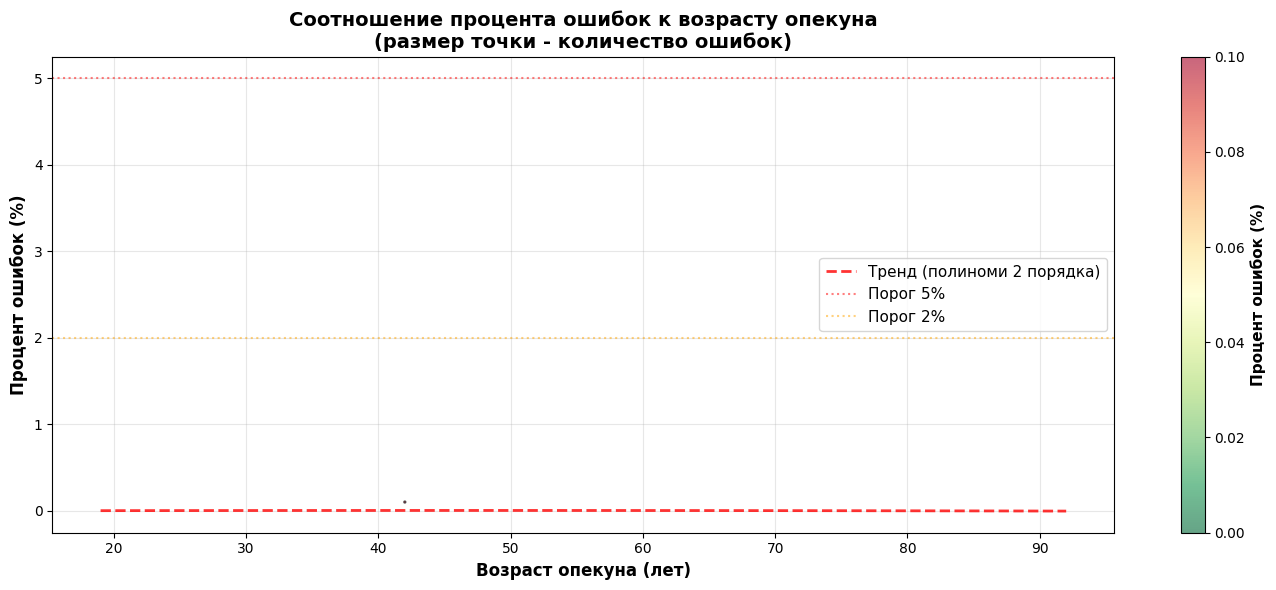


📈 Статистика по возрасту опекуна:
   Минимальный возраст: 19 лет
   Максимальный возраст: 92 лет
   Средний процент ошибок: 0.00%
   Максимальный процент ошибок: 0.10% (возраст 42 лет)
   Минимальный процент ошибок: 0.00% (возраст 19 лет)


In [26]:
# ========== ГРАФИК 5: ПРОЦЕНТ ОШИБОК ПО ВОЗРАСТУ ОПЕКУНА ==========
print("\n" + "="*60)
print("АНАЛИЗ ОШИБОК ПО ВОЗРАСТУ ОПЕКУНА")
print("="*60)

# Удаляем строки где нет данных о возрасте опекуна
df_with_guard_age = df[df['guard_age_years'].notna()].copy()

# Группируем по возрасту опекуна
guard_age_stats = df_with_guard_age.groupby('guard_age_years').agg({
    'is_invalid': ['sum', 'count']
}).round(2)

guard_age_stats.columns = ['invalid_count', 'total_in_age']
guard_age_stats['invalid_pct'] = (guard_age_stats['invalid_count'] / guard_age_stats['total_in_age'] * 100).round(2)
guard_age_stats = guard_age_stats.sort_index()

print("\n📊 Статистика по возрасту опекуна:")
print(f"   Всего уникальных возрастов: {len(guard_age_stats)}")
print(f"\n🔍 Первые 10 возрастов:")
print(guard_age_stats.head(10).to_string())

fig, ax = plt.subplots(figsize=(14, 6))

ages = guard_age_stats.index.astype(int)
pct_invalid = guard_age_stats['invalid_pct'].values
invalid_counts = guard_age_stats['invalid_count'].values

# График с размером точек в зависимости от количества ошибок
scatter = ax.scatter(ages, pct_invalid, s=invalid_counts*2, alpha=0.6, c=pct_invalid, cmap='RdYlGn_r', edgecolors='black', linewidth=1)

# Добавляем линию тренда
z = np.polyfit(ages, pct_invalid, 2)
p = np.poly1d(z)
ax.plot(ages, p(ages), "r--", alpha=0.8, linewidth=2, label='Тренд (полиноми 2 порядка)')

ax.set_xlabel('Возраст опекуна (лет)', fontsize=12, fontweight='bold')
ax.set_ylabel('Процент ошибок (%)', fontsize=12, fontweight='bold')
ax.set_title('Соотношение процента ошибок к возрасту опекуна\n(размер точки - количество ошибок)', fontsize=14, fontweight='bold')
ax.axhline(y=5, color='red', linestyle=':', label='Порог 5%', alpha=0.5)
ax.axhline(y=2, color='orange', linestyle=':', label='Порог 2%', alpha=0.5)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Добавляем цветовую шкалу
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Процент ошибок (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Дополнительная статистика
print(f"\n📈 Статистика по возрасту опекуна:")
print(f"   Минимальный возраст: {ages.min()} лет")
print(f"   Максимальный возраст: {ages.max()} лет")
print(f"   Средний процент ошибок: {pct_invalid.mean():.2f}%")
print(f"   Максимальный процент ошибок: {pct_invalid.max():.2f}% (возраст {ages[pct_invalid.argmax()]} лет)")
print(f"   Минимальный процент ошибок: {pct_invalid.min():.2f}% (возраст {ages[pct_invalid.argmin()]} лет)")


In [27]:
# ========== ОБЪЕДИНЕНИЕ ДУБЛИКАТОВ: ОДИН ДЕНЬ + ОДИНАКОВЫЙ РЕЗУЛЬТАТ ==========
print("\n" + "="*60)
print("ОБЪЕДИНЕНИЕ ДУБЛИКАТОВ (ОДИН ДЕНЬ + ОДИНАКОВЫЙ РЕЗУЛЬТАТ)")
print("="*60)

# Создаем уникальный ключ: ребенок (по ФИО + дата рождения) + дата теста + результат
df['child_key'] = (df['last_name'].fillna('') + '|' +
                   df['first_name'].fillna('') + '|' +
                   df['bdate'].astype(str))

df['test_key'] = df['child_key'] + '|' + df['test_date'].astype(str) + '|' + df['result_code'].astype(str)

# Находим дубликаты
duplicates_mask = df.duplicated(subset=['test_key'], keep='first')
duplicate_count = duplicates_mask.sum()
df['is_duplicated'] = False
print(f"\n📊 Статистика дубликатов:")
print(f"   Всего записей: {len(df)}")
print(f"   Дубликатов (одинаковый день + результат): {duplicate_count} ({duplicate_count/len(df)*100:.2f}%)")

if duplicate_count > 0:
    # Отмечаем дубликаты как технические ошибки
    df.loc[duplicates_mask, 'is_duplicated'] = True

    # Показываем примеры дубликатов
    print(f"\n⚠️  Примеры дубликатов (первые 10):")
    duplicate_keys = df[duplicates_mask]['test_key'].head(10)
    for i, key in enumerate(duplicate_keys, 1):
        matching_rows = df[df['test_key'] == key]
        print(f"   {i}. Ребенок: {matching_rows.iloc[0]['first_name']} {matching_rows.iloc[0]['last_name']}")
        print(f"      Дата: {matching_rows.iloc[0]['test_date'].date()} | Результат: {matching_rows.iloc[0]['result']}")
        print(f"      Количество дубликатов в этот день: {len(matching_rows)}")


print(f"\n✅ Отмечено {duplicate_count} дубликатов как is_tech_error")

# Просмотр дубликатов перед удалением
if duplicate_count > 0:
    print(f"\n📋 Все дубликаты ({duplicate_count} записей):")
    duplicated_records = df[df['is_duplicated'] == True][['last_name', 'first_name', 'test_date', 'result', 'is_invalid', 'is_tech_error']].head(20)
    print(duplicated_records.to_string())
    if duplicate_count > 20:
        print(f"\n   ... и ещё {duplicate_count - 20} записей")

# Не удаляем дубликаты, а просто помечаем их
print(f"\n📍 Дубликаты помечены, но не удалены")
print(f"   Всего записей: {len(df)}")
print(f"   Дубликатов помечено: {duplicate_count}")

# Очищаем временные колонки
df = df.drop(['child_key', 'test_key'], axis=1)

print(f"\n✅ Дубликаты успешно помечены гофлагом is_duplicated и is_tech_error!")



ОБЪЕДИНЕНИЕ ДУБЛИКАТОВ (ОДИН ДЕНЬ + ОДИНАКОВЫЙ РЕЗУЛЬТАТ)

📊 Статистика дубликатов:
   Всего записей: 25628
   Дубликатов (одинаковый день + результат): 633 (2.47%)

⚠️  Примеры дубликатов (первые 10):
   1. Ребенок: АЛЕКСАНДР КАМНЕВ
      Дата: 2025-12-04 | Результат: Недостаточный
      Количество дубликатов в этот день: 2
   2. Ребенок: ЕВГЕНИЙ ЖИГАЛОВ
      Дата: 2026-02-19 | Результат: Недостаточный
      Количество дубликатов в этот день: 2
   3. Ребенок: ВИКТОР КИРЕЕВ
      Дата: 2025-05-07 | Результат: достаточный
      Количество дубликатов в этот день: 2
   4. Ребенок: ГЕННАДИЙ МАЛАНИН
      Дата: 2025-08-20 | Результат: Недостаточный
      Количество дубликатов в этот день: 2
   5. Ребенок: ОЛЕГ СОКОЛОВ
      Дата: 2025-11-19 | Результат: Достаточный
      Количество дубликатов в этот день: 2
   6. Ребенок: ИГОРЬ ЛУТАЙ
      Дата: 2025-05-28 | Результат: недостаточный
      Количество дубликатов в этот день: 3
   7. Ребенок: ИГОРЬ ЛУТАЙ
      Дата: 2025-05-28 | Результат: н

In [28]:
# ========== ВАЛИДАЦИЯ ОГРН ==========
print("\n" + "="*60)
print("ВАЛИДАЦИЯ ОГРН")
print("="*60)

import re

def validate_ogrn(ogrn: str, is_ip: bool = False) -> bool:
    """
    Валидирует ОГРН по контрольной сумме
    ОГРН может быть 13 символов (для ЮЛ) или 15 (для ИП)
    """
    if pd.isna(ogrn):
        return True  # пропускаем пустые значения

    try:
        ogrn_str = str(ogrn).strip()

        # Проверяем длину
        if len(ogrn_str) != 13 and len(ogrn_str) != 15:
            return False

        # Проверяем что только цифры
        if not re.fullmatch(r'[1-9][0-9]+', ogrn_str):
            return False

        # Проверяем контрольную сумму для ЮЛ (13 символов)
        if len(ogrn_str) == 13:
            checksum = int(ogrn_str[:-1]) % 11 % 10
            if checksum != int(ogrn_str[12]):
                return False

        # Проверяем контрольную сумму для ИП (15 символов)
        elif len(ogrn_str) == 15:
            checksum = int(ogrn_str[:-1]) % 13 % 10
            if checksum != int(ogrn_str[14]):
                return False

        return True
    except:
        return False

# Применяем валидацию к ogrn_area
if 'ogrn_area' in df.columns:
    df['ogrn_valid'] = df['ogrn_area'].apply(validate_ogrn)
    invalid_ogrn_count = (~df['ogrn_valid']).sum()

    # Пметить некорректные ОГРН как is_tech_error
    df.loc[~df['ogrn_valid'], 'is_tech_error'] = True

    print(f"\n📊 Статистика валидации ОГРН:")
    print(f"   Всего записей: {len(df)}")
    print(f"   ✅ Валидных ОГРН: {df['ogrn_valid'].sum()}")
    print(f"   ❌ Невалидных ОГРН: {invalid_ogrn_count} ({invalid_ogrn_count/len(df)*100:.2f}%)")

    if invalid_ogrn_count > 0:
        print(f"\n⚠️  Примеры невалидных ОГРН (первые 10):")
        invalid_ogrn_samples = df[~df['ogrn_valid']]['ogrn_area'].head(10)
        for i, ogrn in enumerate(invalid_ogrn_samples, 1):
            print(f"   {i}. {ogrn}")
else:
    print("\n⚠️  Колонка ogrn_area не найдена")



ВАЛИДАЦИЯ ОГРН

📊 Статистика валидации ОГРН:
   Всего записей: 25628
   ✅ Валидных ОГРН: 25628
   ❌ Невалидных ОГРН: 0 (0.00%)



АНАЛИЗ ОШИБОК ПО РЕГИОНАМ (ИЗ ОГРН)

📊 Извлекаем коды регионов из валидных ОГРН...

📊 Статистика по регионам (топ 20):
             invalid_count  total_in_region  invalid_pct
region_code                                             
71                       1              637         0.16
1                        0               85         0.00
66                       0             1672         0.00
64                       0              241         0.00
63                       0              447         0.00
62                       0              247         0.00
61                       0              342         0.00
60                       0               77         0.00
59                       0              290         0.00
58                       0              178         0.00
57                       0               74         0.00
56                       0              390         0.00
55                       0              192         0.00
54                       

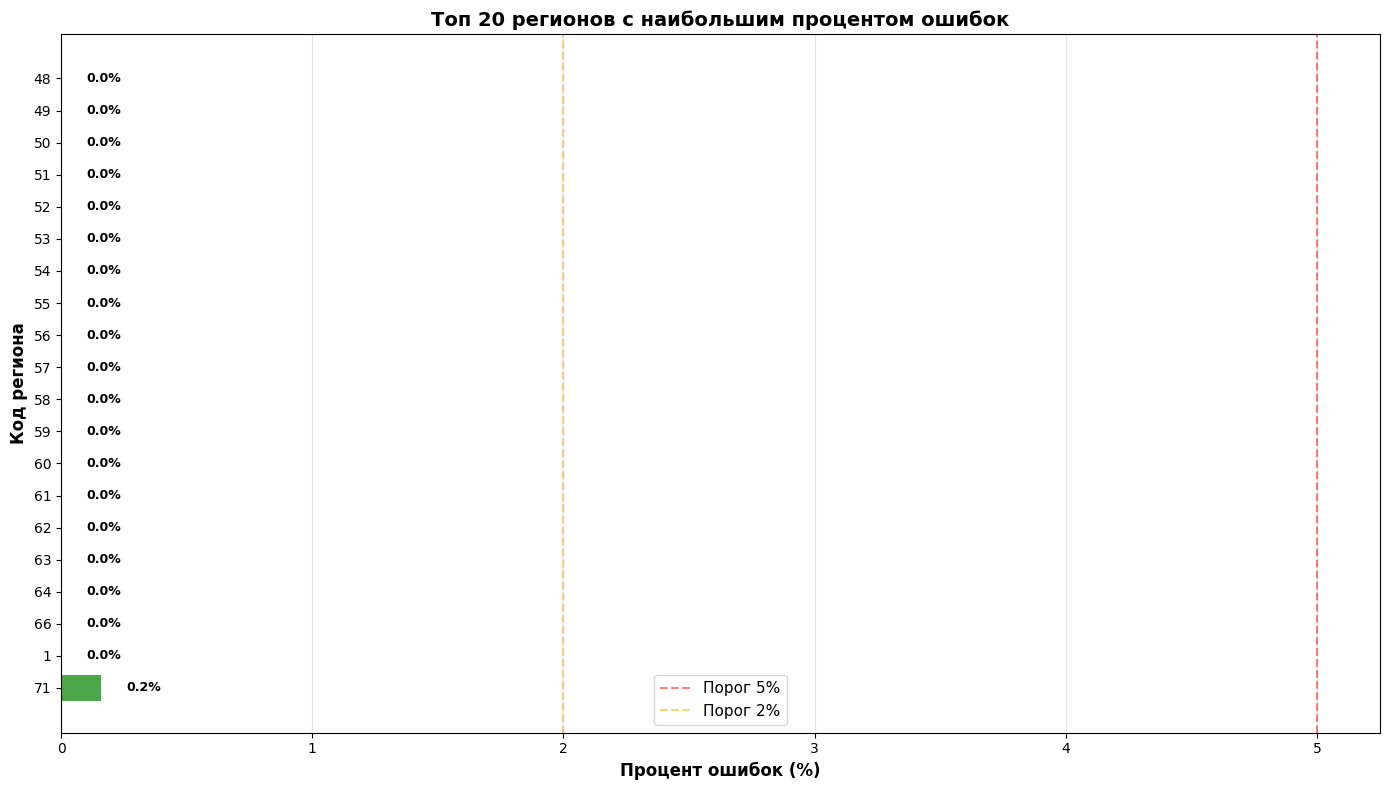


📈 Общая статистика по регионам:
   Всего регионов: 87
   Средний процент ошибок: 0.00%
   Максимальный процент ошибок: 0.16%
   Минимальный процент ошибок: 0.00%


In [29]:
# ========== АНАЛИЗ ОШИБОК ПО РЕГИОНУ (ОГРН) ==========
print("\n" + "="*60)
print("АНАЛИЗ ОШИБОК ПО РЕГИОНАМ (ИЗ ОГРН)")
print("="*60)

# Функция для извлечения кода региона из ОГРН
def extract_region_code_from_ogrn(ogrn):
    """Извлекает код региона (4-5 позиции) из ОГРН"""
    if pd.isna(ogrn):
        return None

    ogrn_str = str(ogrn).strip()

    # ОГРН содержит 13 или 15 цифр, код региона на позициях 4-5 (индексы 3-4)
    if len(ogrn_str) >= 5 and ogrn_str.isdigit():
        try:
            region_code = int(ogrn_str[3:5])
            return region_code
        except:
            return None

    return None

# Извлекаем код региона только из валидных ОГРН
print(f"\n📊 Извлекаем коды регионов из валидных ОГРН...")

if 'ogrn_area' in df.columns and 'ogrn_valid' in df.columns:
    df['region_code'] = df['ogrn_area'].apply(extract_region_code_from_ogrn)

    # Статистика по регионам
    df_with_region = df[df['region_code'].notna()].copy()

    if len(df_with_region) > 0:
        region_stats = df_with_region.groupby('region_code').agg({
            'is_invalid': ['sum', 'count']
        }).round(2)

        region_stats.columns = ['invalid_count', 'total_in_region']
        region_stats['invalid_pct'] = (region_stats['invalid_count'] / region_stats['total_in_region'] * 100).round(2)
        region_stats = region_stats.sort_values('invalid_pct', ascending=False)

        print(f"\n📊 Статистика по регионам (топ 20):")
        print(region_stats[['invalid_count', 'total_in_region', 'invalid_pct']].head(20).to_string())

        # График по регионам
        fig, ax = plt.subplots(figsize=(14, 8))

        # Берем топ 20 регионов по проценту ошибок
        top_regions = region_stats.head(20).copy()

        colors_regions = ['red' if p > 5 else 'orange' if p > 2 else 'green' for p in top_regions['invalid_pct'].values]

        bars = ax.barh(range(len(top_regions)), top_regions['invalid_pct'].values, color=colors_regions, alpha=0.7)

        # Добавляем коды регионов
        ax.set_yticks(range(len(top_regions)))
        ax.set_yticklabels([f'{int(code)}' for code in top_regions.index], fontsize=10)

        ax.set_xlabel('Процент ошибок (%)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Код региона', fontsize=12, fontweight='bold')
        ax.set_title('Топ 20 регионов с наибольшим процентом ошибок', fontsize=14, fontweight='bold')
        ax.axvline(x=5, color='red', linestyle='--', label='Порог 5%', alpha=0.5)
        ax.axvline(x=2, color='orange', linestyle='--', label='Порог 2%', alpha=0.5)
        ax.legend(fontsize=11)
        ax.grid(axis='x', alpha=0.3)

        # Добавляем значения на концах полос
        for i, (idx, row) in enumerate(top_regions.iterrows()):
            ax.text(row['invalid_pct'] + 0.1, i, f"{row['invalid_pct']:.1f}%",
                   va='center', fontsize=9, fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Общая статистика по регионам
        print(f"\n📈 Общая статистика по регионам:")
        print(f"   Всего регионов: {len(region_stats)}")
        print(f"   Средний процент ошибок: {region_stats['invalid_pct'].mean():.2f}%")
        print(f"   Максимальный процент ошибок: {region_stats['invalid_pct'].max():.2f}%")
        print(f"   Минимальный процент ошибок: {region_stats['invalid_pct'].min():.2f}%")
    else:
        print("\n⚠️  Не удалось извлечь коды регионов из ogrn_area")
else:
    print("\n⚠️  Колонка ogrn_area не найдена")


In [30]:
# ========== АНАЛИЗ НАРУШЕНИЙ ПО РЕГИОНАМ (С РАЗЛИЧНЫМИ ФИЛЬТРАМИ) ==========
print("\n" + "="*60)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ НАРУШЕНИЙ ПО РЕГИОНАМ")
print("="*60)

if 'region_code' in df.columns:
    # Вариант 1: ВСЕ ЗАПИСИ (включая is_invalid и is_tech_error)
    print(f"\n📊 Вариант 1: ВСЕ ЗАПИСИ (включая ошибки)")
    region_stats_all = df.groupby('region_code').agg({
        'is_invalid': ['sum', 'count']
    }).round(2)
    region_stats_all.columns = ['invalid_count', 'total_in_region']
    region_stats_all['invalid_pct'] = (region_stats_all['invalid_count'] / region_stats_all['total_in_region'] * 100).round(2)
    region_stats_all = region_stats_all.sort_values('invalid_pct', ascending=False)

    print(f"   Топ 10 регионов по проценту ошибок:")
    print(region_stats_all[['invalid_count', 'total_in_region', 'invalid_pct']].head(10).to_string())

    # Вариант 2: БЕЗ ТЕХНИЧЕСКИХ ОШИБОК (только is_invalid, но не is_tech_error)
    print(f"\n📊 Вариант 2: БЕЗ ТЕХНИЧЕСКИХ ОШИБОК")
    df_without_tech = df[~df['is_tech_error']].copy()
    region_stats_no_tech = df_without_tech.groupby('region_code').agg({
        'is_invalid': ['sum', 'count']
    }).round(2)
    region_stats_no_tech.columns = ['invalid_count', 'total_in_region']
    region_stats_no_tech['invalid_pct'] = (region_stats_no_tech['invalid_count'] / region_stats_no_tech['total_in_region'] * 100).round(2)
    region_stats_no_tech = region_stats_no_tech.sort_values('invalid_pct', ascending=False)

    print(f"   Топ 10 регионов по проценту ошибок (без техошибок):")
    print(region_stats_no_tech[['invalid_count', 'total_in_region', 'invalid_pct']].head(10).to_string())

    # Вариант 3: ТОЛЬКО ЧИСТЫЕ ДАННЫЕ (no is_invalid и no is_tech_error)
    print(f"\n📊 Вариант 3: ТОЛЬКО ЧИСТЫЕ ДАННЫЕ (без всех ошибок)")
    df_clean = df[(~df['is_invalid']) & (~df['is_tech_error'])].copy()
    total_clean = len(df_clean)
    total_all = len(df)
    print(f"   Объем чистых данных: {total_clean} записей из {total_all} ({total_clean/total_all*100:.2f}%)")

    region_stats_clean = df_clean.groupby('region_code').agg({
        'is_invalid': 'count'
    }).round(2)
    region_stats_clean.columns = ['clean_count']
    region_stats_clean = region_stats_clean.sort_values('clean_count', ascending=False)

    print(f"   Топ 10 регионов по количеству чистых записей:")
    print(region_stats_clean.head(10).to_string())



СРАВНИТЕЛЬНЫЙ АНАЛИЗ НАРУШЕНИЙ ПО РЕГИОНАМ

📊 Вариант 1: ВСЕ ЗАПИСИ (включая ошибки)
   Топ 10 регионов по проценту ошибок:
             invalid_count  total_in_region  invalid_pct
region_code                                             
71                       1              637         0.16
1                        0               85         0.00
66                       0             1672         0.00
64                       0              241         0.00
63                       0              447         0.00
62                       0              247         0.00
61                       0              342         0.00
60                       0               77         0.00
59                       0              290         0.00
58                       0              178         0.00

📊 Вариант 2: БЕЗ ТЕХНИЧЕСКИХ ОШИБОК
   Топ 10 регионов по проценту ошибок (без техошибок):
             invalid_count  total_in_region  invalid_pct
region_code                               

In [31]:
# ========== АНАЛИЗ НАРУШЕНИЙ ЧАСТОТЫ ТЕСТИРОВАНИЯ ПО РЕГИОНАМ ==========
print("\n" + "="*60)
print("АНАЛИЗ НАРУШЕНИЙ ЧАСТОТЫ ТЕСТИРОВАНИЯ ПО РЕГИОНАМ")
print("="*60)

# Создаем уникальный идентификатор для каждого ребенка
def create_child_id(row):
    """Создает уникальный ID ребенка"""
    parts = []
    if pd.notna(row['bdate']):
        parts.append(str(row['bdate']))
    if pd.notna(row['id_doc']):
        parts.append(str(int(row['id_doc'])))
    if pd.notna(row['last_name']):
        parts.append(str(row['last_name']).upper())
    if pd.notna(row['first_name']):
        parts.append(str(row['first_name']).upper())
    if not parts:
        return f"UNKNOWN_{id(row)}"
    return '|'.join(parts)

df['child_id'] = df.apply(create_child_id, axis=1)

# Создаем флаг для нарушений частоты тестирования (интервал < 60 или > 120 дней)
df['freq_violation'] = False

# Проверяем интервалы между тестами для каждого ребенка
for child_id in df['child_id'].unique():
    child_tests = df[df['child_id'] == child_id].sort_values('test_date').copy()

    if len(child_tests) > 1:
        dates = child_tests['test_date'].values
        indices = child_tests.index.values

        for i in range(len(dates) - 1):
            # Вычисляем интервал в днях
            interval_days = (dates[i + 1] - dates[i]) / pd.Timedelta(days=1)

            # Проверяем отклонение от рекомендуемых 90 дней
            if interval_days < 60 or interval_days > 120:
                df.loc[indices[i + 1], 'freq_violation'] = True

freq_violation_count = df['freq_violation'].sum()
print(f"\n📊 Статистика нарушений частоты тестирования:")
print(f"   Всего записей: {len(df)}")
print(f"   Нарушений частоты (интервал < 60 или > 120 дней): {freq_violation_count} ({freq_violation_count/len(df)*100:.2f}%)")



АНАЛИЗ НАРУШЕНИЙ ЧАСТОТЫ ТЕСТИРОВАНИЯ ПО РЕГИОНАМ

📊 Статистика нарушений частоты тестирования:
   Всего записей: 25628
   Нарушений частоты (интервал < 60 или > 120 дней): 1597 (6.23%)



ГИСТОГРАММА НАРУШЕНИЙ ЧАСТОТЫ ПО РЕГИОНАМ

📊 Статистика по вариантам:

   Вариант 1 (ВСЕ ЗАПИСИ):
      Топ 10 регионов по количеству нарушений:
             violations_count  total_count  violation_pct
region_code                                              
77                        482         2627          18.35
66                         88         1672           5.26
50                         76         1723           4.41
16                         65          731           8.89
36                         57          402          14.18
68                         49          240          20.42
74                         41          847           4.84
47                         41          832           4.93
63                         38          447           8.50
78                         38         1306           2.91

   Вариант 2 (БЕЗ ТЕХНИЧЕСКИХ ОШИБОК):
      Топ 10 регионов по количеству нарушений:
             violations_count  total_count  violation_pct
region_code  

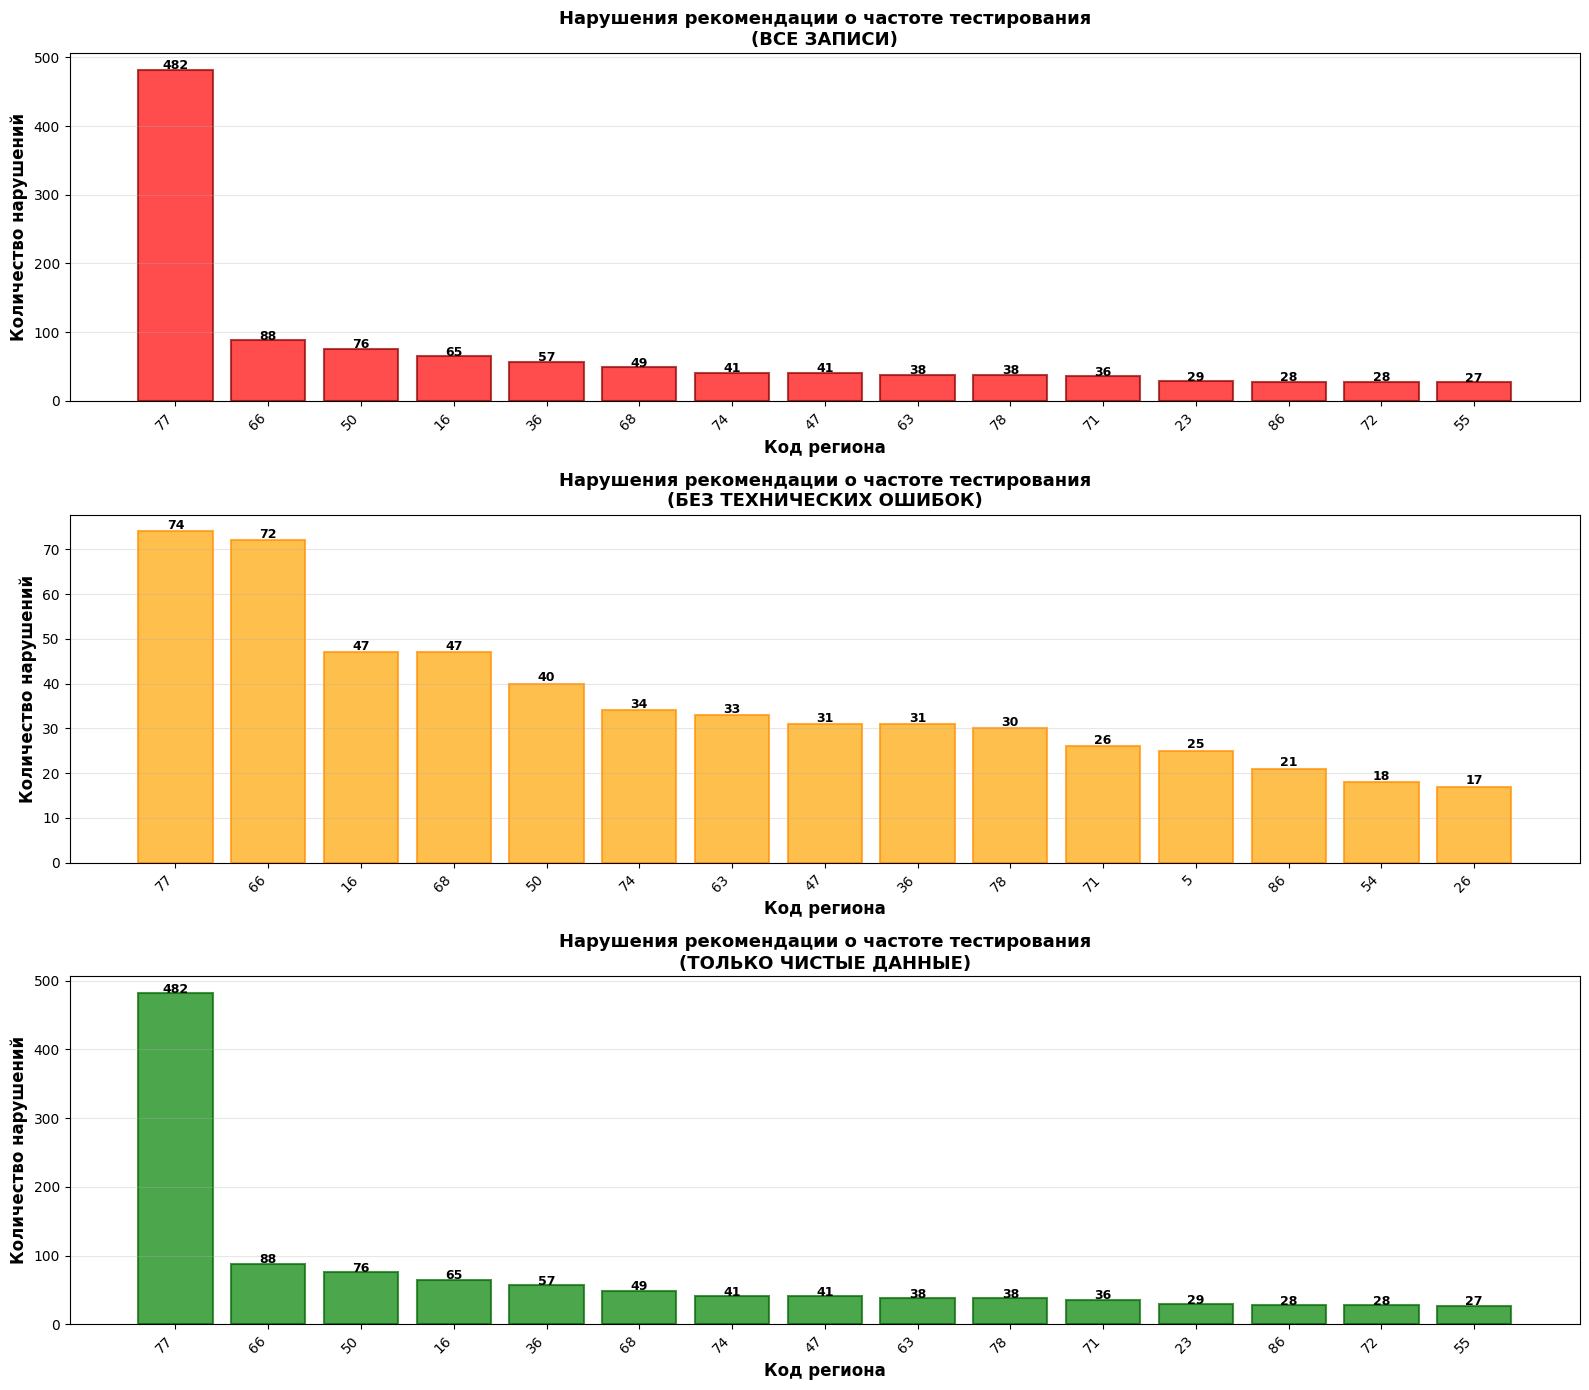


✅ Гистограммы нарушений по регионам построены успешно!


In [32]:
# ========== ГРАФИК 6: ГИСТОГРАММА НАРУШЕНИЙ ПО РЕГИОНАМ (3 варианта) ==========
print("\n" + "="*60)
print("ГИСТОГРАММА НАРУШЕНИЙ ЧАСТОТЫ ПО РЕГИОНАМ")
print("="*60)

if 'region_code' in df.columns:
    # Вариант 1: ВСЕ ЗАПИСИ
    region_freq_all = df.groupby('region_code').agg({
        'freq_violation': 'sum'
    }).round(0).astype(int)
    region_freq_all.columns = ['violations_count']
    region_freq_all['total_count'] = df.groupby('region_code').size()
    region_freq_all['violation_pct'] = (region_freq_all['violations_count'] / region_freq_all['total_count'] * 100).round(2)
    region_freq_all = region_freq_all.sort_values('violations_count', ascending=False)

    # Вариант 2: БЕЗ ТЕХНИЧЕСКИХ ОШИБОК
    df_without_tech = df[~df['is_tech_error']].copy()
    region_freq_no_tech = df_without_tech.groupby('region_code').agg({
        'freq_violation': 'sum'
    }).round(0).astype(int)
    region_freq_no_tech.columns = ['violations_count']
    region_freq_no_tech['total_count'] = df_without_tech.groupby('region_code').size()
    region_freq_no_tech['violation_pct'] = (region_freq_no_tech['violations_count'] / region_freq_no_tech['total_count'] * 100).round(2)
    region_freq_no_tech = region_freq_no_tech.sort_values('violations_count', ascending=False)

    # Вариант 3: ТОЛЬКО ЧИСТЫЕ ДАННЫЕ (без is_invalid и is_tech_error)
    df_clean = df[(~df['is_invalid'])].copy()
    region_freq_clean = df_clean.groupby('region_code').agg({
        'freq_violation': 'sum'
    }).round(0).astype(int)
    region_freq_clean.columns = ['violations_count']
    region_freq_clean['total_count'] = df_clean.groupby('region_code').size()
    region_freq_clean['violation_pct'] = (region_freq_clean['violations_count'] / region_freq_clean['total_count'] * 100).round(2)
    region_freq_clean = region_freq_clean.sort_values('violations_count', ascending=False)

    print(f"\n📊 Статистика по вариантам:")
    print(f"\n   Вариант 1 (ВСЕ ЗАПИСИ):")
    print(f"      Топ 10 регионов по количеству нарушений:")
    print(region_freq_all[['violations_count', 'total_count', 'violation_pct']].head(10).to_string())

    print(f"\n   Вариант 2 (БЕЗ ТЕХНИЧЕСКИХ ОШИБОК):")
    print(f"      Топ 10 регионов по количеству нарушений:")
    print(region_freq_no_tech[['violations_count', 'total_count', 'violation_pct']].head(10).to_string())

    print(f"\n   Вариант 3 (ТОЛЬКО ЧИСТЫЕ ДАННЫЕ):")
    print(f"      Топ 10 регионов по количеству нарушений:")
    print(region_freq_clean[['violations_count', 'total_count', 'violation_pct']].head(10).to_string())

    # Гистограмма
    fig, axes = plt.subplots(3, 1, figsize=(16, 14))

    # График 1: ВСЕ ЗАПИСИ
    ax1 = axes[0]
    top15_all = region_freq_all.head(15)
    bars1 = ax1.bar(range(len(top15_all)), top15_all['violations_count'].values, color='red', alpha=0.7, edgecolor='darkred', linewidth=1.5)
    ax1.set_xlabel('Код региона', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Количество нарушений', fontsize=12, fontweight='bold')
    ax1.set_title('Нарушения рекомендации о частоте тестирования\n(ВСЕ ЗАПИСИ)', fontsize=13, fontweight='bold')
    ax1.set_xticks(range(len(top15_all)))
    ax1.set_xticklabels([f'{int(code)}' for code in top15_all.index], rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)
    # Добавляем значения на столбцах
    for i, (idx, row) in enumerate(top15_all.iterrows()):
        ax1.text(i, row['violations_count'] + 0.5, f"{int(row['violations_count'])}", ha='center', fontsize=9, fontweight='bold')

    # График 2: БЕЗ ТЕХНИЧЕСКИХ ОШИБОК
    ax2 = axes[1]
    top15_no_tech = region_freq_no_tech.head(15)
    bars2 = ax2.bar(range(len(top15_no_tech)), top15_no_tech['violations_count'].values, color='orange', alpha=0.7, edgecolor='darkorange', linewidth=1.5)
    ax2.set_xlabel('Код региона', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Количество нарушений', fontsize=12, fontweight='bold')
    ax2.set_title('Нарушения рекомендации о частоте тестирования\n(БЕЗ ТЕХНИЧЕСКИХ ОШИБОК)', fontsize=13, fontweight='bold')
    ax2.set_xticks(range(len(top15_no_tech)))
    ax2.set_xticklabels([f'{int(code)}' for code in top15_no_tech.index], rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    # Добавляем значения на столбцах
    for i, (idx, row) in enumerate(top15_no_tech.iterrows()):
        ax2.text(i, row['violations_count'] + 0.5, f"{int(row['violations_count'])}", ha='center', fontsize=9, fontweight='bold')

    # График 3: ТОЛЬКО ЧИСТЫЕ ДАННЫЕ
    ax3 = axes[2]
    top15_clean = region_freq_clean.head(15)
    bars3 = ax3.bar(range(len(top15_clean)), top15_clean['violations_count'].values, color='green', alpha=0.7, edgecolor='darkgreen', linewidth=1.5)
    ax3.set_xlabel('Код региона', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Количество нарушений', fontsize=12, fontweight='bold')
    ax3.set_title('Нарушения рекомендации о частоте тестирования\n(ТОЛЬКО ЧИСТЫЕ ДАННЫЕ)', fontsize=13, fontweight='bold')
    ax3.set_xticks(range(len(top15_clean)))
    ax3.set_xticklabels([f'{int(code)}' for code in top15_clean.index], rotation=45, ha='right')
    ax3.grid(axis='y', alpha=0.3)
    # Добавляем значения на столбцах
    for i, (idx, row) in enumerate(top15_clean.iterrows()):
        ax3.text(i, row['violations_count'] + 0.5, f"{int(row['violations_count'])}", ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n✅ Гистограммы нарушений по регионам построены успешно!")



ВИЗУАЛИЗАЦИЯ: СРАВНЕНИЕ НАРУШЕНИЙ ПО РЕГИОНАМ


/var/folders/th/n3z6xrp16p5bnl3r73s06dfc0000gn/T/ipykernel_68543/795111720.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/th/n3z6xrp16p5bnl3r73s06dfc0000gn/T/ipykernel_68543/795111720.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/semolik/PyCharmMiscProject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/semolik/PyCharmMiscProject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


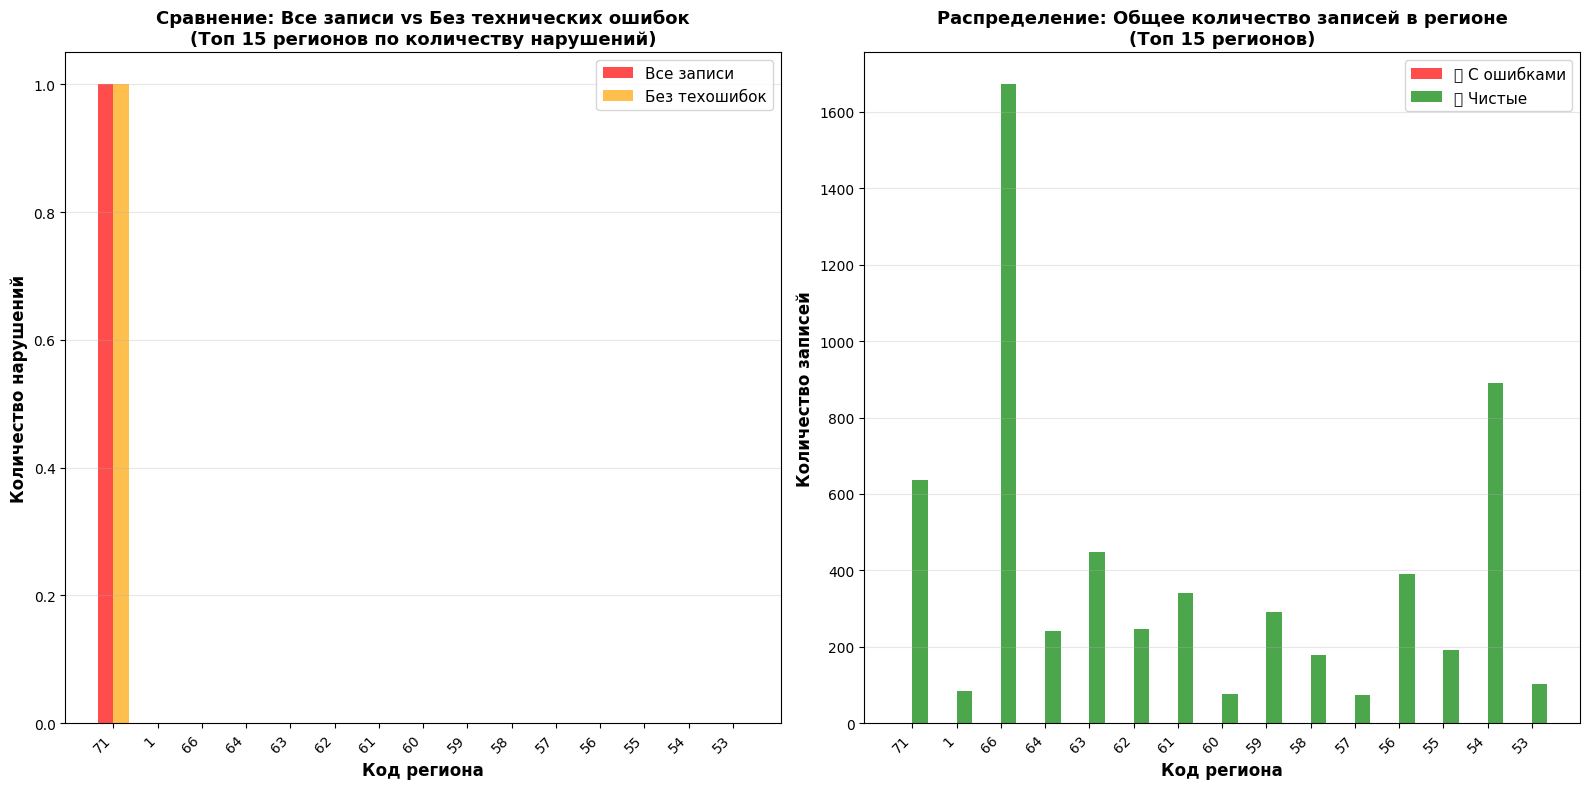


✅ Графики сравнения построены успешно!


In [33]:
# ========== ГРАФИК 7: СРАВНЕНИЕ НАРУШЕНИЙ ПО РЕГИОНАМ (3 варианта) ==========
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ: СРАВНЕНИЕ НАРУШЕНИЙ ПО РЕГИОНАМ")
print("="*60)

if 'region_code' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Левый график: ВСЕ ЗАПИСИ vs БЕЗ ТЕХОШИБОК (по КОЛИЧЕСТВУ нарушений)
    ax1 = axes[0]
    top_regions_all = region_stats_all.head(15).copy()
    top_regions_no_tech = region_stats_no_tech.loc[top_regions_all.index].copy() if any(top_regions_all.index.isin(region_stats_no_tech.index)) else region_stats_no_tech.head(15)

    x_pos = np.arange(len(top_regions_all))
    width = 0.35

    bars1 = ax1.bar(x_pos - width/2, top_regions_all['invalid_count'].values, width, label='Все записи', color='red', alpha=0.7)
    bars2 = ax1.bar(x_pos + width/2, top_regions_no_tech.loc[top_regions_all.index, 'invalid_count'].values if any(top_regions_all.index.isin(region_stats_no_tech.index)) else 0, width, label='Без техошибок', color='orange', alpha=0.7)

    ax1.set_xlabel('Код региона', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Количество нарушений', fontsize=12, fontweight='bold')
    ax1.set_title('Сравнение: Все записи vs Без технических ошибок\n(Топ 15 регионов по количеству нарушений)', fontsize=13, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'{int(code)}' for code in top_regions_all.index], rotation=45, ha='right')
    ax1.legend(fontsize=11)
    ax1.grid(axis='y', alpha=0.3)

    # Правый график: ЧИСТЫЕ ДАННЫЕ vs ОШИБОЧНЫЕ
    ax2 = axes[1]
    top_regions_compare = region_stats_all.head(15).copy()
    top_regions_compare['clean_count'] = top_regions_compare['total_in_region'] - top_regions_compare['invalid_count']

    x_pos2 = np.arange(len(top_regions_compare))
    ax2.bar(x_pos2 - width/2, top_regions_compare['invalid_count'].values, width, label='❌ С ошибками', color='red', alpha=0.7)
    ax2.bar(x_pos2 + width/2, top_regions_compare['clean_count'].values, width, label='✅ Чистые', color='green', alpha=0.7)

    ax2.set_xlabel('Код региона', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Количество записей', fontsize=12, fontweight='bold')
    ax2.set_title('Распределение: Общее количество записей в регионе\n(Топ 15 регионов)', fontsize=13, fontweight='bold')
    ax2.set_xticks(x_pos2)
    ax2.set_xticklabels([f'{int(code)}' for code in top_regions_compare.index], rotation=45, ha='right')
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n✅ Графики сравнения построены успешно!")


In [34]:
# ========== ГРАФИК 8: ГИСТОГРАММА НАРУШЕНИЙ ЧАСТОТЫ ТЕСТИРОВАНИЯ ПО РЕГИОНАМ ==========
print("\n" + "="*60)
print("АНАЛИЗ: НАРУШЕНИЯ ЧАСТОТЫ ТЕСТИРОВАНИЯ ПО РЕГИОНАМ")
print("="*60)

# Анализируем нарушения частоты (60-120 дней) по регионам
if 'region_code' in df.columns and 'interval_days' not in locals():
    # Создаем уникальный ключ для идентификации детей
    df['child_combo_key'] = (df['last_name'].fillna('') + '|' +
                             df['first_name'].fillna('') + '|' +
                             df['bdate'].astype(str))

    # Анализируем интервалы между тестами
    frequency_violations = []

    for child_key in df['child_combo_key'].unique():
        child_data = df[df['child_combo_key'] == child_key].sort_values('test_date').copy()

        if len(child_data) > 1:
            dates = child_data['test_date'].values
            region_codes = child_data['region_code'].values
            indices = child_data.index.values

            for i in range(len(dates) - 1):
                interval_days = (dates[i + 1] - dates[i]) / pd.Timedelta(days=1)

                # Проверяем нарушение (вне 60-120 дней)
                if interval_days < 60 or interval_days > 120:
                    region_code = region_codes[i]
                    frequency_violations.append({
                        'region_code': region_code,
                        'interval_days': interval_days,
                        'violation_type': 'SHORT' if interval_days < 60 else 'LONG'
                    })

    if frequency_violations:
        violations_df = pd.DataFrame(frequency_violations)

        # Статистика по регионам
        region_violations = violations_df.groupby('region_code').agg({
            'violation_type': 'count'
        }).rename(columns={'violation_type': 'violation_count'})
        region_violations = region_violations.sort_values('violation_count', ascending=False)

        # Подробная статистика
        region_violations['short_interval'] = violations_df[violations_df['violation_type'] == 'SHORT'].groupby('region_code').size()
        region_violations['long_interval'] = violations_df[violations_df['violation_type'] == 'LONG'].groupby('region_code').size()
        region_violations = region_violations.fillna(0).astype(int)

        print(f"\n📊 Статистика нарушений по регионам (топ 20):")
        print(region_violations.head(20).to_string())

        print(f"\n📈 Общая статистика нарушений частоты:")
        print(f"   Всего нарушений: {len(violations_df)}")
        print(f"   Нарушений с коротким интервалом (< 60 дней): {len(violations_df[violations_df['violation_type'] == 'SHORT'])}")
        print(f"   Нарушений с длинным интервалом (> 120 дней): {len(violations_df[violations_df['violation_type'] == 'LONG'])}")

        #  Вариант 1: Только нарушения
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        # Левый график: Все нарушения по регионам
        top_violations = region_violations.head(15).copy()
        ax1 = axes[0]

        colors_violations = ['red' if v < 60 or v > 120 else 'green' for v in top_violations.index]
        bars = ax1.bar(range(len(top_violations)), top_violations['violation_count'].values, color='darkred', alpha=0.7)

        ax1.set_xlabel('Код региона', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Количество нарушений частоты', fontsize=12, fontweight='bold')
        ax1.set_title('Нарушения рекомендации о частоте тестирования\n(Не чаще 1 раза в 3 месяца, т.е. 60-120 дней)\nТоп 15 регионов', fontsize=13, fontweight='bold')
        ax1.set_xticks(range(len(top_violations)))
        ax1.set_xticklabels([f'{int(code)}' for code in top_violations.index], rotation=45, ha='right')
        ax1.grid(axis='y', alpha=0.3)

        # Добавляем значения на столбцы
        for i, (idx, row) in enumerate(top_violations.iterrows()):
            ax1.text(i, row['violation_count'] + 5, f"{int(row['violation_count'])}",
                    ha='center', fontsize=9, fontweight='bold')

        # Правый график: Разделение по типам нарушений
        ax2 = axes[1]
        x_pos = np.arange(len(top_violations))
        width = 0.4

        short_intervals = top_violations['short_interval'].values
        long_intervals = top_violations['long_interval'].values

        bars1 = ax2.bar(x_pos - width/2, short_intervals, width, label='Короткий интервал (< 60 дн)', color='orange', alpha=0.7)
        bars2 = ax2.bar(x_pos + width/2, long_intervals, width, label='Длинный интервал (> 120 дн)', color='purple', alpha=0.7)

        ax2.set_xlabel('Код региона', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Количество нарушений', fontsize=12, fontweight='bold')
        ax2.set_title('Типы нарушений по регионам\n(Топ 15 регионов)', fontsize=13, fontweight='bold')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels([f'{int(code)}' for code in top_violations.index], rotation=45, ha='right')
        ax2.legend(fontsize=11)
        ax2.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("\n✅ Графики нарушений частоты построены успешно!")
    else:
        print("\n⚠️  Нарушений частоты тестирования не найдено")



АНАЛИЗ: НАРУШЕНИЯ ЧАСТОТЫ ТЕСТИРОВАНИЯ ПО РЕГИОНАМ



ГИСТОГРАММЫ: КОЛИЧЕСТВО НАРУШЕНИЙ ПО РЕГИОНАМ


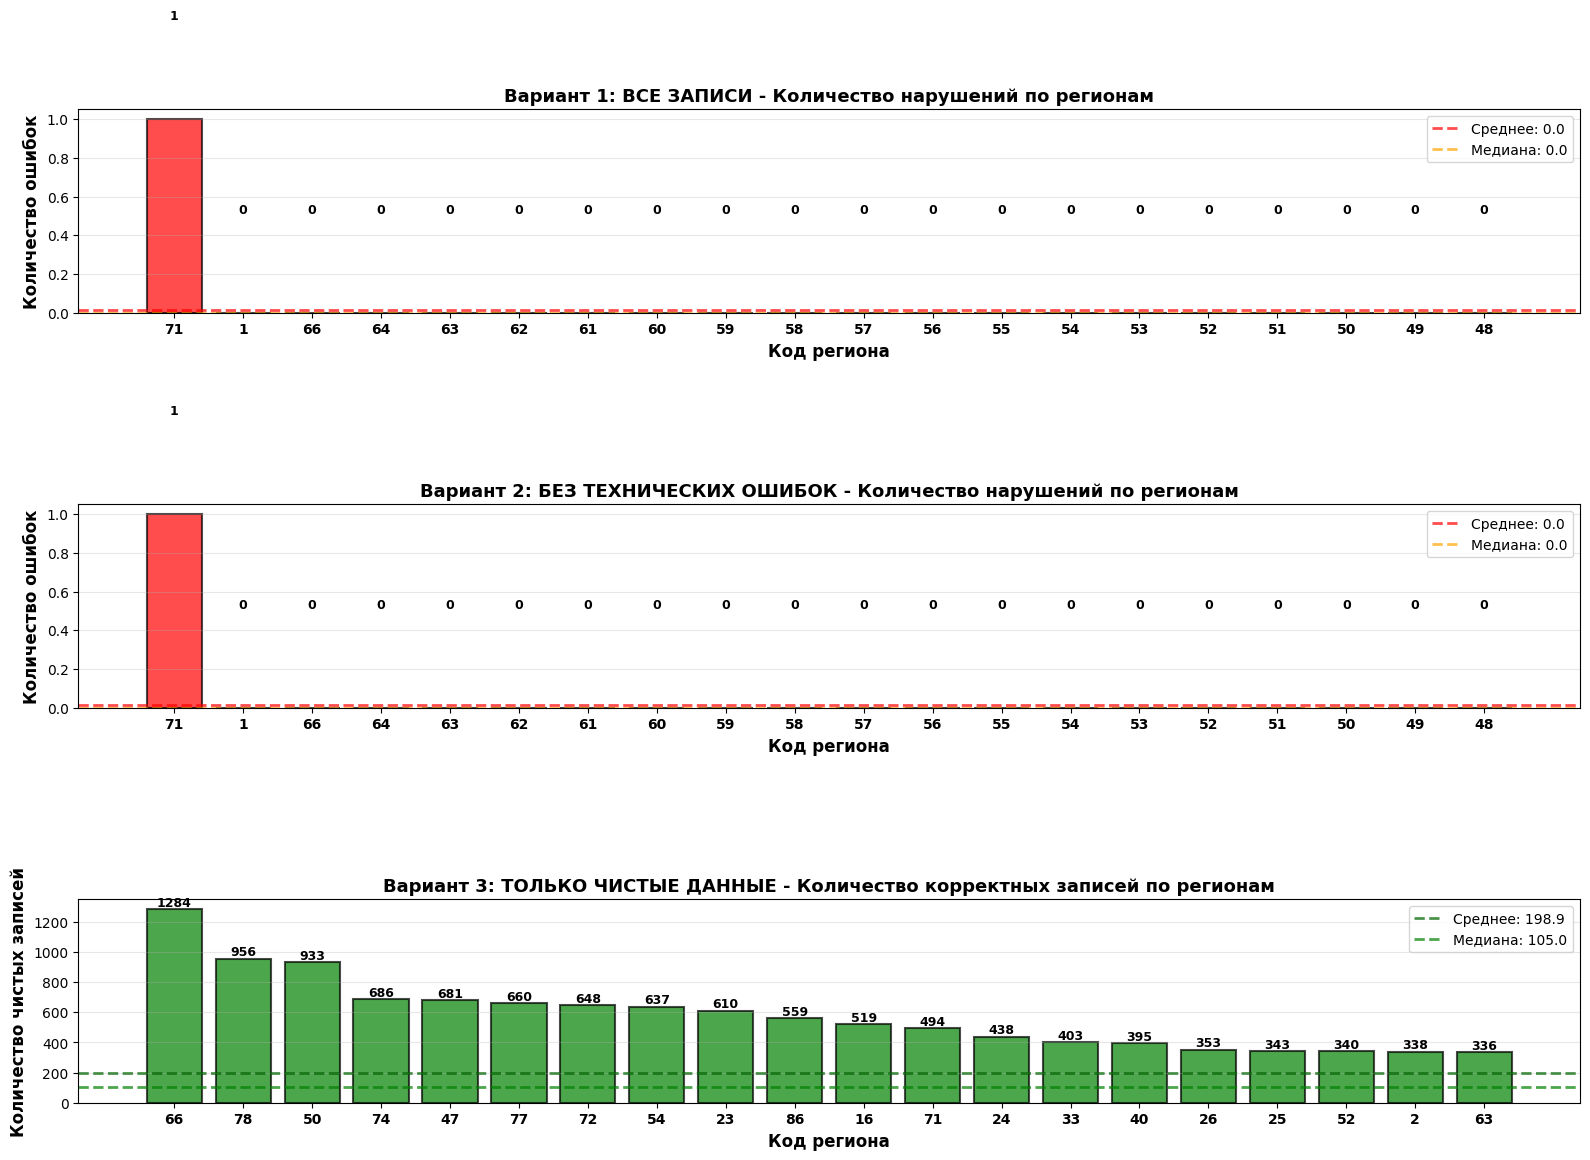


📊 Итоговая сводка по регионам:

   Вариант 1 (ВСЕ ЗАПИСИ):
      Всего ошибок: 1
      Средние ошибок на регион: 0.01
      Медиана ошибок: 0.00

   Вариант 2 (БЕЗ ТЕХНИЧЕСКИХ ОШИБОК):
      Всего ошибок: 1
      Средние ошибок на регион: 0.01
      Медиана ошибок: 0.00

   Вариант 3 (ЧИСТЫЕ ДАННЫЕ):
      Всего чистых записей: 17306
      Средние чистых записей на регион: 198.92
      Медиана чистых записей: 105.00

✅ Гистограммы нарушений по регионам построены успешно!


In [35]:
# ========== ГРАФИК 7: ГИСТОГРАММЫ НАРУШЕНИЙ ПО РЕГИОНАМ (3 ВАРИАНТА) ==========
print("\n" + "="*60)
print("ГИСТОГРАММЫ: КОЛИЧЕСТВО НАРУШЕНИЙ ПО РЕГИОНАМ")
print("="*60)

if 'region_code' in df.columns:
    # Вариант 1: ВСЕ ЗАПИСИ
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))

    # --- Вариант 1: ВСЕ ЗАПИСИ ---
    ax1 = axes[0]
    region_invalid_all = df.groupby('region_code')['is_invalid'].sum().sort_values(ascending=False)
    top_regions_bad = region_invalid_all.head(20)

    colors_invalid = ['red' if val > region_invalid_all.mean() else 'orange' if val > region_invalid_all.median() else 'yellow' for val in top_regions_bad.values]
    bars1 = ax1.bar(range(len(top_regions_bad)), top_regions_bad.values, color=colors_invalid, alpha=0.7, edgecolor='black', linewidth=1.5)

    ax1.set_xticks(range(len(top_regions_bad)))
    ax1.set_xticklabels([f'{int(code)}' for code in top_regions_bad.index], fontsize=10, fontweight='bold')
    ax1.set_xlabel('Код региона', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Количество ошибок', fontsize=12, fontweight='bold')
    ax1.set_title('Вариант 1: ВСЕ ЗАПИСИ - Количество нарушений по регионам', fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбца
    for i, (idx, val) in enumerate(top_regions_bad.items()):
        ax1.text(i, val + 0.5, f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Добавляем средние линии
    ax1.axhline(y=region_invalid_all.mean(), color='red', linestyle='--', label=f'Среднее: {region_invalid_all.mean():.1f}', alpha=0.7, linewidth=2)
    ax1.axhline(y=region_invalid_all.median(), color='orange', linestyle='--', label=f'Медиана: {region_invalid_all.median():.1f}', alpha=0.7, linewidth=2)
    ax1.legend(fontsize=10)

    # --- Вариант 2: БЕЗ ТЕХНИЧЕСКИХ ОШИБОК ---
    ax2 = axes[1]
    df_no_tech = df[~df['is_tech_error']].copy()
    region_invalid_no_tech = df_no_tech.groupby('region_code')['is_invalid'].sum().sort_values(ascending=False)
    top_regions_no_tech_bad = region_invalid_no_tech.head(20)

    colors_no_tech = ['red' if val > region_invalid_no_tech.mean() else 'orange' if val > region_invalid_no_tech.median() else 'yellow' for val in top_regions_no_tech_bad.values]
    bars2 = ax2.bar(range(len(top_regions_no_tech_bad)), top_regions_no_tech_bad.values, color=colors_no_tech, alpha=0.7, edgecolor='black', linewidth=1.5)

    ax2.set_xticks(range(len(top_regions_no_tech_bad)))
    ax2.set_xticklabels([f'{int(code)}' for code in top_regions_no_tech_bad.index], fontsize=10, fontweight='bold')
    ax2.set_xlabel('Код региона', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Количество ошибок', fontsize=12, fontweight='bold')
    ax2.set_title('Вариант 2: БЕЗ ТЕХНИЧЕСКИХ ОШИБОК - Количество нарушений по регионам', fontsize=13, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбца
    for i, (idx, val) in enumerate(top_regions_no_tech_bad.items()):
        ax2.text(i, val + 0.5, f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Добавляем средние линии
    ax2.axhline(y=region_invalid_no_tech.mean(), color='red', linestyle='--', label=f'Среднее: {region_invalid_no_tech.mean():.1f}', alpha=0.7, linewidth=2)
    ax2.axhline(y=region_invalid_no_tech.median(), color='orange', linestyle='--', label=f'Медиана: {region_invalid_no_tech.median():.1f}', alpha=0.7, linewidth=2)
    ax2.legend(fontsize=10)

    # --- Вариант 3: ТОЛЬКО ЧИСТЫЕ ДАННЫЕ ---
    ax3 = axes[2]
    df_clean = df[(~df['is_invalid']) & (~df['is_tech_error'])].copy()
    # Считаем количество чистых записей по регионам
    region_clean = df_clean.groupby('region_code').size().sort_values(ascending=False)
    top_regions_clean = region_clean.head(20)

    colors_clean = ['green' if val > region_clean.mean() else 'lightgreen' for val in top_regions_clean.values]
    bars3 = ax3.bar(range(len(top_regions_clean)), top_regions_clean.values, color=colors_clean, alpha=0.7, edgecolor='black', linewidth=1.5)

    ax3.set_xticks(range(len(top_regions_clean)))
    ax3.set_xticklabels([f'{int(code)}' for code in top_regions_clean.index], fontsize=10, fontweight='bold')
    ax3.set_xlabel('Код региона', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Количество чистых записей', fontsize=12, fontweight='bold')
    ax3.set_title('Вариант 3: ТОЛЬКО ЧИСТЫЕ ДАННЫЕ - Количество корректных записей по регионам', fontsize=13, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбца
    for i, (idx, val) in enumerate(top_regions_clean.items()):
        ax3.text(i, val + 0.5, f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Добавляем средние линии
    ax3.axhline(y=region_clean.mean(), color='darkgreen', linestyle='--', label=f'Среднее: {region_clean.mean():.1f}', alpha=0.7, linewidth=2)
    ax3.axhline(y=region_clean.median(), color='green', linestyle='--', label=f'Медиана: {region_clean.median():.1f}', alpha=0.7, linewidth=2)
    ax3.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n📊 Итоговая сводка по регионам:")
    print(f"\n   Вариант 1 (ВСЕ ЗАПИСИ):")
    print(f"      Всего ошибок: {region_invalid_all.sum()}")
    print(f"      Средние ошибок на регион: {region_invalid_all.mean():.2f}")
    print(f"      Медиана ошибок: {region_invalid_all.median():.2f}")

    print(f"\n   Вариант 2 (БЕЗ ТЕХНИЧЕСКИХ ОШИБОК):")
    print(f"      Всего ошибок: {region_invalid_no_tech.sum()}")
    print(f"      Средние ошибок на регион: {region_invalid_no_tech.mean():.2f}")
    print(f"      Медиана ошибок: {region_invalid_no_tech.median():.2f}")

    print(f"\n   Вариант 3 (ЧИСТЫЕ ДАННЫЕ):")
    print(f"      Всего чистых записей: {len(df_clean)}")
    print(f"      Средние чистых записей на регион: {region_clean.mean():.2f}")
    print(f"      Медиана чистых записей: {region_clean.median():.2f}")

    print("\n✅ Гистограммы нарушений по регионам построены успешно!")


In [36]:
# ========== ОБЩАЯ СВОДКА ПО КОЛИЧЕСТВАМ ВСЕХ ТИПОВ ОШИБОК И ЗАПИСЕЙ ==========
print("\n" + "="*80)
print("📊 ПОЛНАЯ СВОДКА: РАСПРЕДЕЛЕНИЕ ЗАПИСЕЙ ПО ТИПАМ")
print("="*80)

# Считаем все типы записей
total_records = len(df)
valid_records = (~df['is_invalid'] & ~df['is_tech_error']).sum()
invalid_records = df['is_invalid'].sum()
tech_error_records = df['is_tech_error'].sum()
both_errors = (df['is_invalid'] & df['is_tech_error']).sum()

# Дополнительные данные о дубликатах (если есть колонка)
duplicated_records = df['is_duplicated'].sum() if 'is_duplicated' in df.columns else 0

print(f"\n📈 ОСНОВНАЯ СТАТИСТИКА:")
print(f"   {'Всего записей:':<40} {total_records:>6}")
print(f"   {'Корректные записи:':<40} {valid_records:>6} ({valid_records/total_records*100:>6.2f}%)")
print(f"   {'Записи с ошибками:':<40} {invalid_records:>6} ({invalid_records/total_records*100:>6.2f}%)")
print(f"   {'Записи с техническими ошибками:':<40} {tech_error_records:>6} ({tech_error_records/total_records*100:>6.2f}%)")
print(f"   {'Записи с обоими типами ошибок:':<40} {both_errors:>6} ({both_errors/total_records*100:>6.2f}%)")

if 'is_duplicated' in df.columns and duplicated_records > 0:
    print(f"   {'Дубликаты:':<40} {duplicated_records:>6} ({duplicated_records/total_records*100:>6.2f}%)")

# Категоризация записей
print(f"\n🔍 КАТЕГОРИЗАЦИЯ ЗАПИСЕЙ:")

# 1. Полностью корректные
clean_data = (~df['is_invalid'] & ~df['is_tech_error']).sum()
print(f"\n   1️⃣  ПОЛНОСТЬЮ КОРРЕКТНЫЕ (без всех ошибок):")
print(f"      {clean_data:>6} записей ({clean_data/total_records*100:>6.2f}%)")

# 2. Только ошибки валидации (нет технических ошибок)
only_invalid = (df['is_invalid'] & ~df['is_tech_error']).sum()
print(f"\n   2️⃣  ТОЛЬКО ОШИБКИ ВАЛИДАЦИИ (нет техошибок):")
print(f"      {only_invalid:>6} записей ({only_invalid/total_records*100:>6.2f}%)")

# 3. Только технические ошибки (нет ошибок валидации)
only_tech = (~df['is_invalid'] & df['is_tech_error']).sum()
print(f"\n   3️⃣  ТОЛЬКО ТЕХНИЧЕСКИЕ ОШИБКИ (нет валидации):")
print(f"      {only_tech:>6} записей ({only_tech/total_records*100:>6.2f}%)")

# 4. Обе ошибки
both = (df['is_invalid'] & df['is_tech_error']).sum()
print(f"\n   4️⃣  ОБЕ ОШИБКИ (и валидация, и техошибки):")
print(f"      {both:>6} записей ({both/total_records*100:>6.2f}%)")

# Финальная проверка (должно быть 100%)
total_check = clean_data + only_invalid + only_tech + both
print(f"\n   ✅ Проверка суммы: {total_check} = {total_records} ✓" if total_check == total_records else f"\n   ❌ ОШИБКА СУММЫ: {total_check} ≠ {total_records}")

# Графическое представление
print(f"\n📊 ВИЗУАЛЬНОЕ РАСПРЕДЕЛЕНИЕ:")
print(f"\n   Корректные:           {'█' * int(clean_data/total_records*50)} {clean_data/total_records*100:.1f}%")
print(f"   Только валидация:     {'█' * int(only_invalid/total_records*50)} {only_invalid/total_records*100:.1f}%")
print(f"   Только техошибки:     {'█' * int(only_tech/total_records*50)} {only_tech/total_records*100:.1f}%")
print(f"   Обе ошибки:           {'█' * int(both/total_records*50)} {both/total_records*100:.1f}%")

# Детальная информация по колонкам
print(f"\n🔐 ДЕТАЛЬНАЯ ИНФОРМАЦИЯ ПО КОЛОНКАМ:")
print(f"\n   is_invalid: {df['is_invalid'].sum()} записей (значение True)")
print(f"   is_tech_error: {df['is_tech_error'].sum()} записей (значение True)")
if 'is_duplicated' in df.columns:
    print(f"   is_duplicated: {df['is_duplicated'].sum()} записей (значение True)")

# Сводка основных типов ошибок (если есть информация)
print(f"\n📋 ПРИМЕРЫ ОШИБОК:")

# Показываем примеры каждого типа ошибок
if only_invalid > 0:
    print(f"\n   Пример ошибки валидации:")
    sample_invalid = df[df['is_invalid'] & ~df['is_tech_error']].head(1)
    if len(sample_invalid) > 0:
        print(f"      {sample_invalid[['last_name', 'first_name', 'test_date', 'is_invalid', 'is_tech_error']].values[0]}")

if only_tech > 0:
    print(f"\n   Пример технической ошибки:")
    sample_tech = df[~df['is_invalid'] & df['is_tech_error']].head(1)
    if len(sample_tech) > 0:
        print(f"      {sample_tech[['last_name', 'first_name', 'test_date', 'is_invalid', 'is_tech_error']].values[0]}")

if both > 0:
    print(f"\n   Пример записи с обоими типами ошибок:")
    sample_both = df[df['is_invalid'] & df['is_tech_error']].head(1)
    if len(sample_both) > 0:
        print(f"      {sample_both[['last_name', 'first_name', 'test_date', 'is_invalid', 'is_tech_error']].values[0]}")

print("\n" + "="*80)



📊 ПОЛНАЯ СВОДКА: РАСПРЕДЕЛЕНИЕ ЗАПИСЕЙ ПО ТИПАМ

📈 ОСНОВНАЯ СТАТИСТИКА:
   Всего записей:                            25628
   Корректные записи:                        17306 ( 67.53%)
   Записи с ошибками:                            1 (  0.00%)
   Записи с техническими ошибками:            8321 ( 32.47%)
   Записи с обоими типами ошибок:                0 (  0.00%)
   Дубликаты:                                  633 (  2.47%)

🔍 КАТЕГОРИЗАЦИЯ ЗАПИСЕЙ:

   1️⃣  ПОЛНОСТЬЮ КОРРЕКТНЫЕ (без всех ошибок):
       17306 записей ( 67.53%)

   2️⃣  ТОЛЬКО ОШИБКИ ВАЛИДАЦИИ (нет техошибок):
           1 записей (  0.00%)

   3️⃣  ТОЛЬКО ТЕХНИЧЕСКИЕ ОШИБКИ (нет валидации):
        8321 записей ( 32.47%)

   4️⃣  ОБЕ ОШИБКИ (и валидация, и техошибки):
           0 записей (  0.00%)

   ✅ Проверка суммы: 25628 = 25628 ✓

📊 ВИЗУАЛЬНОЕ РАСПРЕДЕЛЕНИЕ:

   Корректные:           █████████████████████████████████ 67.5%
   Только валидация:      0.0%
   Только техошибки:     ████████████████ 32.5%
   Обе оши

In [37]:
# save dataset

output_path = 'cleaned_dataset.csv'
df.to_csv(output_path, index=False)
print(f"\n✅ Очищенный и дополненный датасет сохранен в файл: {output_path}")


✅ Очищенный и дополненный датасет сохранен в файл: cleaned_dataset.csv


In [38]:


df[df['is_invalid'] == True].shape[0]

1

In [39]:
df[df['is_logical_error'] == True].shape[0]


141

In [40]:
df[df['same_doc_id_error'] == True].shape


(347, 38)

In [41]:
df[df['is_duplicated'] == True].shape

(633, 38)

In [42]:
df[df['is_tech_error'] == True].shape

(8321, 38)

In [43]:
df[df['is_invalid'] == True].shape[0] + df[df['is_logical_error'] == True].shape[0] + df[df['same_doc_id_error'] == True].shape[0] + df[df['is_duplicated'] == True].shape[0]

1122

In [44]:
filter_mask = ((df['is_invalid'] == False) & (df['is_logical_error'] == False) & (df['same_doc_id_error'] == False) & (df['is_duplicated'] == False))

df_clean = df[filter_mask].copy()
print(f"\n✅ Чистый датасет создан: {len(df_clean)} записей без ошибок валидации, логических ошибок, дубликатов и технических ошибок.")


✅ Чистый датасет создан: 24518 записей без ошибок валидации, логических ошибок, дубликатов и технических ошибок.


In [45]:
df.shape[0] - df_clean.shape[0]

1110